# Libraries and functions

In [3]:
from pathlib import Path
import json
import itertools
import math

import torch
import numpy as np
import matplotlib.pyplot as plt


def _as_list(x):
    return x if isinstance(x, list) else [x]


def _cartesian_product_like_driver(grid):
    keys = sorted(grid.keys())
    values_lists = [_as_list(grid[k]) for k in keys]

    combos = []
    for values in itertools.product(*values_lists):
        combos.append({k: v for k, v in zip(keys, values)})

    return combos


def _get_times_and_blocks(payload):
    if "times" in payload and "by_time" in payload:
        return payload["times"], payload["by_time"]

    if "epochs" in payload and "by_epoch" in payload:
        return payload["epochs"], payload["by_epoch"]

    raise ValueError("Unknown SVD payload format.")


def load_all_svd_once(
    results_dir,
    config_path,
    *,
    svd_filename="svd_diagnostics.pt",
    value_keys=("gram_eigenvalues", "singular_values"),
):
    """
    Load all SVD diagnostics once.

    Returns a store that can be reused for any plotting without reading files again.

    store["data"][(a,b)]["by_time"][epoch][layer_name]["gram_eigenvalues"]
    store["data"][(a,b)]["by_time"][epoch][layer_name]["singular_values"]
    """
    results_dir = Path(results_dir)
    config_path = Path(config_path)

    cfg = json.loads(config_path.read_text())
    grid = cfg["grid"]

    lr_values = _as_list(grid["lr"])
    inv_sigma_w_values = _as_list(grid["inv_sigma_w"])

    combos = _cartesian_product_like_driver(grid)

    store = {
        "results_dir": results_dir,
        "config_path": config_path,
        "lr_values": lr_values,
        "inv_sigma_w_values": inv_sigma_w_values,
        "combos": combos,
        "data": {},
    }

    for a, lr in enumerate(lr_values):
        for b, inv_sigma_w in enumerate(inv_sigma_w_values):

            matching_combo_indices = []
            for combo_index, combo in enumerate(combos):
                if (
                    float(combo.get("lr")) == float(lr)
                    and float(combo.get("inv_sigma_w")) == float(inv_sigma_w)
                ):
                    matching_combo_indices.append(combo_index)

            if len(matching_combo_indices) == 0:
                continue

            if len(matching_combo_indices) > 1:
                print(
                    f"[WARN] More than one combo matches (a,b)=({a},{b}). "
                    f"I will use the first one: {matching_combo_indices[0]}"
                )

            combo_index = matching_combo_indices[0]
            combo = combos[combo_index]

            combo_dirs = sorted(results_dir.glob(f"combo_{combo_index:04d}_*"))
            if len(combo_dirs) == 0:
                print(f"[WARN] Missing folder for combo_index={combo_index}, (a,b)=({a},{b})")
                continue

            combo_dir = combo_dirs[0]
            svd_files = sorted(combo_dir.rglob(svd_filename))

            if len(svd_files) == 0:
                print(f"[WARN] No {svd_filename} found for combo_index={combo_index}, (a,b)=({a},{b})")
                continue

            entry = {
                "a": a,
                "b": b,
                "combo_index": combo_index,
                "combo": combo,
                "combo_dir": combo_dir,
                "svd_files": svd_files,
                "by_time": {},
                "layer_order": None,
            }

            for svd_path in svd_files:
                payload = torch.load(svd_path, map_location="cpu")
                times, blocks = _get_times_and_blocks(payload)

                for t in times:
                    t_int = int(t)
                    t_key = str(t_int)
                    if t_key not in blocks:
                        t_key = str(t)

                    block = blocks[t_key]
                    layer_order = block.get("layer_order", list(block["layers"].keys()))

                    if entry["layer_order"] is None:
                        entry["layer_order"] = list(layer_order)

                    if t_int not in entry["by_time"]:
                        entry["by_time"][t_int] = {}

                    for layer_name in layer_order:
                        if layer_name not in entry["by_time"][t_int]:
                            entry["by_time"][t_int][layer_name] = {
                                key: [] for key in value_keys
                            }

                        layer_payload = block["layers"][layer_name]

                        for key in value_keys:
                            if key in layer_payload:
                                vals = np.asarray(layer_payload[key], dtype=np.float64)
                                entry["by_time"][t_int][layer_name][key].append(vals)

            # Concatenate across seeds/files.
            for t in entry["by_time"]:
                for layer_name in entry["by_time"][t]:
                    for key in value_keys:
                        arrays = entry["by_time"][t][layer_name][key]
                        if len(arrays) > 0:
                            entry["by_time"][t][layer_name][key] = np.concatenate(arrays)
                        else:
                            entry["by_time"][t][layer_name][key] = np.array([], dtype=np.float64)

            store["data"][(a, b)] = entry

    print(f"[DONE] loaded {len(store['data'])} available (a,b) combos into memory.")
    return store

/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a,
    b,
    *,
    layers="all",
    value_key="gram_eigenvalues",
    bins=40,
    log_x=True,
    density=True,
    shared_bins="layer",
    figsize_per_panel=(3., 2.6),
    mark_top_singular_values=True,
    top_k_singular=5,
):
    """
    Plot SVD/eigenvalue histograms for one combo (a,b).

    Layout:
        rows    = layers
        columns = evaluation epochs/times

    If mark_top_singular_values=True:
        add red x markers for the top-k largest singular values.

    Important:
        If value_key="singular_values", the red x are placed at the top singular values.
        If value_key="gram_eigenvalues", the red x are placed at singular_value**2,
        because the x-axis is eigenvalues of W W^T.
    """
    key = (a, b)

    if key not in svd_store["data"]:
        raise KeyError(f"No loaded data for combo (a,b)=({a},{b}).")

    entry = svd_store["data"][key]
    by_time = entry["by_time"]
    times = sorted(by_time.keys())

    if layers == "all":
        layer_names = list(entry["layer_order"])
    else:
        layer_names = list(layers)

    n_layers = len(layer_names)
    n_times = len(times)

    if n_layers == 0:
        raise ValueError("No layers to plot.")
    if n_times == 0:
        raise ValueError("No times to plot.")

    values = {}
    top_marker_values = {}

    for layer_name in layer_names:
        values[layer_name] = {}
        top_marker_values[layer_name] = {}

        for t in times:
            if layer_name not in by_time[t]:
                raise KeyError(
                    f"Layer '{layer_name}' not found at epoch/time {t}. "
                    f"Available layers: {list(by_time[t].keys())}"
                )

            if value_key not in by_time[t][layer_name]:
                raise KeyError(
                    f"value_key='{value_key}' not found for layer '{layer_name}' at time {t}. "
                    f"Available keys: {list(by_time[t][layer_name].keys())}"
                )

            vals = np.asarray(by_time[t][layer_name][value_key], dtype=np.float64)

            if log_x:
                vals = vals[vals > 0]

            values[layer_name][t] = vals

            # Top-k singular values for red x markers
            if mark_top_singular_values:
                if "singular_values" not in by_time[t][layer_name]:
                    raise KeyError(
                        f"'singular_values' not found for layer '{layer_name}' at time {t}. "
                        "Cannot mark top singular values."
                    )

                svals = np.asarray(by_time[t][layer_name]["singular_values"], dtype=np.float64)
                svals = svals[np.isfinite(svals)]

                if len(svals) == 0:
                    top_marker_values[layer_name][t] = np.array([], dtype=np.float64)
                else:
                    svals_sorted = np.sort(svals)[::-1]
                    top_svals = svals_sorted[:top_k_singular]

                    if value_key == "singular_values":
                        marker_x = top_svals
                    elif value_key == "gram_eigenvalues":
                        marker_x = top_svals ** 2
                    else:
                        raise ValueError(
                            "mark_top_singular_values only makes sense for "
                            "value_key='singular_values' or value_key='gram_eigenvalues'."
                        )

                    if log_x:
                        marker_x = marker_x[marker_x > 0]

                    top_marker_values[layer_name][t] = marker_x

    def make_bins(arr):
        arr = np.asarray(arr, dtype=np.float64)
        arr = arr[np.isfinite(arr)]

        if len(arr) == 0:
            return None

        if log_x:
            arr = arr[arr > 0]
            if len(arr) == 0:
                return None

            vmin, vmax = arr.min(), arr.max()

            if vmin == vmax:
                vmin *= 0.9
                vmax *= 1.1

            return np.logspace(np.log10(vmin), np.log10(vmax), bins)

        else:
            vmin, vmax = arr.min(), arr.max()

            if vmin == vmax:
                vmin -= 0.5
                vmax += 0.5

            return np.linspace(vmin, vmax, bins)

    global_bins = None
    if shared_bins == "global":
        all_vals = []
        for layer_name in layer_names:
            for t in times:
                all_vals.append(values[layer_name][t])
        global_bins = make_bins(np.concatenate(all_vals))

    layer_bins = {}
    if shared_bins == "layer":
        for layer_name in layer_names:
            all_vals = [values[layer_name][t] for t in times]
            layer_bins[layer_name] = make_bins(np.concatenate(all_vals))

    fig, axes = plt.subplots(
        n_layers,
        n_times,
        figsize=(figsize_per_panel[0] * n_times, figsize_per_panel[1] * n_layers),
        squeeze=False,
    )

    for row, layer_name in enumerate(layer_names):
        for col, t in enumerate(times):
            ax = axes[row, col]
            vals = values[layer_name][t]

            if shared_bins == "global":
                hist_bins = global_bins
            elif shared_bins == "layer":
                hist_bins = layer_bins[layer_name]
            elif shared_bins == "panel":
                hist_bins = make_bins(vals)
            else:
                raise ValueError("shared_bins must be one of: 'layer', 'global', 'panel'.")

            if hist_bins is None or len(vals) == 0:
                ax.text(
                    0.5,
                    0.5,
                    "no values",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
            else:
                counts, _, _ = ax.hist(vals, bins=hist_bins, density=density)

                if mark_top_singular_values:
                    marker_x = top_marker_values[layer_name][t]

                    if len(marker_x) > 0:
                        ymax = ax.get_ylim()[1]
                        marker_y = np.full_like(marker_x, 0.90 * ymax, dtype=np.float64)

                        ax.scatter(
                            marker_x,
                            marker_y,
                            marker="x",
                            color="red",
                            s=55,
                            linewidths=1.5,
                            zorder=10,
                            label=f"top {top_k_singular}" if row == 0 and col == 0 else None,
                        )

            if log_x:
                ax.set_xscale("log")

            if row == 0:
                ax.set_title(f"epoch = {t}")

            if col == 0:
                ax.set_ylabel(f"{layer_name}\n" + ("density" if density else "count"))

            if row == n_layers - 1:
                if value_key == "gram_eigenvalues":
                    ax.set_xlabel(r"eigenvalues of $W W^T$")
                else:
                    ax.set_xlabel("singular values")

    if mark_top_singular_values:
        axes[0, 0].legend(loc="best", fontsize=8)

    combo = entry["combo"]

    fig.suptitle(
        f"combo ({a},{b}) | combo_index={entry['combo_index']} | "
        f"lr={combo['lr']} | inv_sigma_w={combo['inv_sigma_w']}",
        y=1.01,
        fontsize=13,
    )

    fig.tight_layout()

    return fig, axes

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list,
    validation_times,
    *,
    layer,
    value_key="gram_eigenvalues",
    bins=40,
    log_x=True,
    density=True,
    shared_bins="combo",
    figsize_per_panel=(3.6, 2.7),
):
    """
    Plot SVD/eigenvalue histograms for one selected layer.

    Layout:
        rows    = selected hyperparameter combos (a,b)
        columns = selected validation times / epochs

    Parameters
    ----------
    svd_store:
        Output of load_all_svd_once(...).

    combo_list:
        List of tuples:
            [(a1,b1), (a2,b2), ...]

    validation_times:
        List of validation epochs/times to plot:
            [1, 10, 50, 300]

    layer:
        Name of the layer to plot, for example:
            "layers.0"
            "layers.1"
            "head.0"

    value_key:
        "gram_eigenvalues" for eigenvalues of W W^T.
        "singular_values" for singular values.

    shared_bins:
        "combo"  -> same bins across selected times for each combo row.
        "global" -> same bins across all combos and times.
        "panel"  -> each panel gets its own bins.
    """
    combo_list = list(combo_list)
    validation_times = [int(t) for t in validation_times]

    if len(combo_list) == 0:
        raise ValueError("combo_list cannot be empty.")

    if len(validation_times) == 0:
        raise ValueError("validation_times cannot be empty.")

    n_rows = len(combo_list)
    n_cols = len(validation_times)

    values = {}

    for combo_ab in combo_list:
        a, b = combo_ab
        key = (a, b)

        if key not in svd_store["data"]:
            raise KeyError(f"No loaded data for combo (a,b)=({a},{b}).")

        entry = svd_store["data"][key]
        by_time = entry["by_time"]

        values[key] = {}

        for t in validation_times:
            if t not in by_time:
                available = sorted(by_time.keys())
                raise KeyError(
                    f"Validation time {t} not found for combo (a,b)=({a},{b}). "
                    f"Available times: {available}"
                )

            if layer not in by_time[t]:
                available_layers = list(by_time[t].keys())
                raise KeyError(
                    f"Layer '{layer}' not found for combo (a,b)=({a},{b}) at time {t}. "
                    f"Available layers: {available_layers}"
                )

            if value_key not in by_time[t][layer]:
                available_keys = list(by_time[t][layer].keys())
                raise KeyError(
                    f"value_key='{value_key}' not found for layer '{layer}' "
                    f"at combo (a,b)=({a},{b}), time={t}. "
                    f"Available keys: {available_keys}"
                )

            vals = np.asarray(by_time[t][layer][value_key], dtype=np.float64)

            if log_x:
                vals = vals[vals > 0]

            values[key][t] = vals

    def make_bins(arr):
        arr = np.asarray(arr, dtype=np.float64)
        arr = arr[np.isfinite(arr)]

        if len(arr) == 0:
            return None

        if log_x:
            arr = arr[arr > 0]
            if len(arr) == 0:
                return None

            vmin = arr.min()
            vmax = arr.max()

            if vmin == vmax:
                vmin *= 0.9
                vmax *= 1.1

            return np.logspace(np.log10(vmin), np.log10(vmax), bins)

        else:
            vmin = arr.min()
            vmax = arr.max()

            if vmin == vmax:
                vmin -= 0.5
                vmax += 0.5

            return np.linspace(vmin, vmax, bins)

    global_bins = None
    if shared_bins == "global":
        all_vals = []
        for key in values:
            for t in validation_times:
                all_vals.append(values[key][t])
        global_bins = make_bins(np.concatenate(all_vals))

    combo_bins = {}
    if shared_bins == "combo":
        for key in values:
            all_vals = [values[key][t] for t in validation_times]
            combo_bins[key] = make_bins(np.concatenate(all_vals))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )

    for row, combo_ab in enumerate(combo_list):
        a, b = combo_ab
        key = (a, b)
        entry = svd_store["data"][key]
        combo = entry["combo"]

        for col, t in enumerate(validation_times):
            ax = axes[row, col]
            vals = values[key][t]

            if shared_bins == "global":
                hist_bins = global_bins
            elif shared_bins == "combo":
                hist_bins = combo_bins[key]
            elif shared_bins == "panel":
                hist_bins = make_bins(vals)
            else:
                raise ValueError("shared_bins must be one of: 'combo', 'global', 'panel'.")

            if hist_bins is None or len(vals) == 0:
                ax.text(
                    0.5,
                    0.5,
                    "no values",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
            else:
                ax.hist(vals, bins=hist_bins, density=density)

            if log_x:
                ax.set_xscale("log")

            if row == 0:
                ax.set_title(f"epoch = {t}")

            if col == 0:
                ax.set_ylabel(
                    f"combo ({a},{b})\n"
                    f"lr={combo['lr']}\n"
                    f"invσ={combo['inv_sigma_w']}\n"
                    + ("density" if density else "count")
                )

            if row == n_rows - 1:
                if value_key == "gram_eigenvalues":
                    ax.set_xlabel(r"eigenvalues of $W W^T$")
                else:
                    ax.set_xlabel("singular values")

    fig.suptitle(
        f"Layer: {layer} | quantity: {value_key}",
        y=1.01,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, axes

# SVD plots 

## DNN

### 1 layer - relu

In [46]:
results_dir = "data/experiment_2/exp2_SVD_dnn_SMALL_sgd_relu_v1"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
)

[DONE] loaded 25 available (a,b) combos into memory.


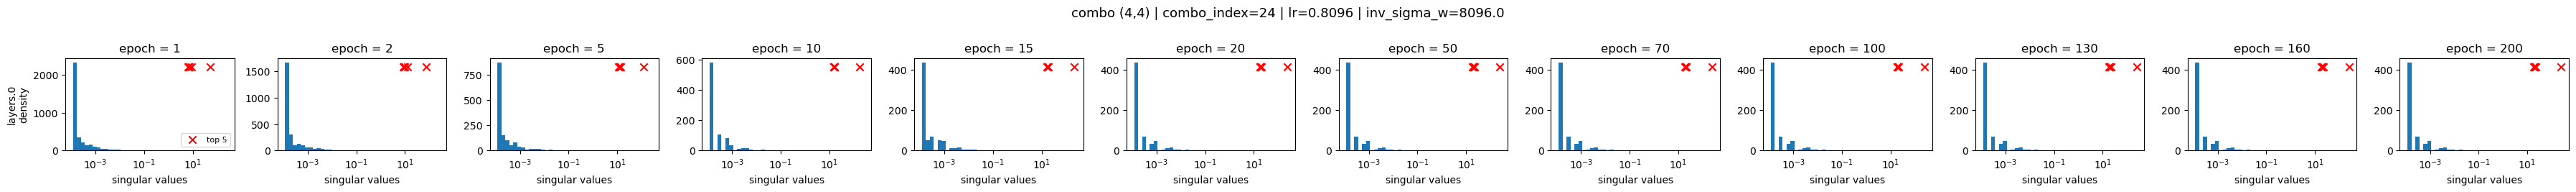

In [36]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

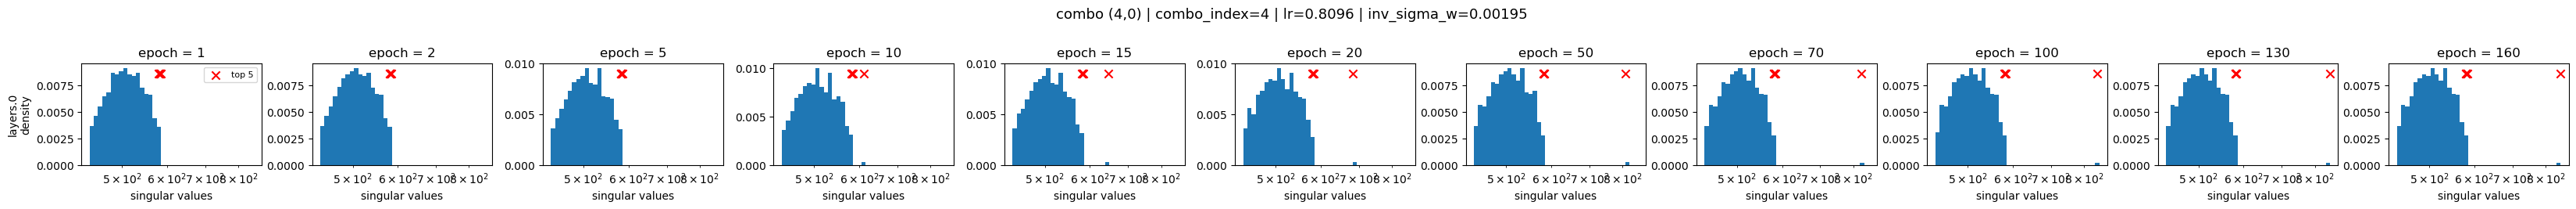

In [37]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

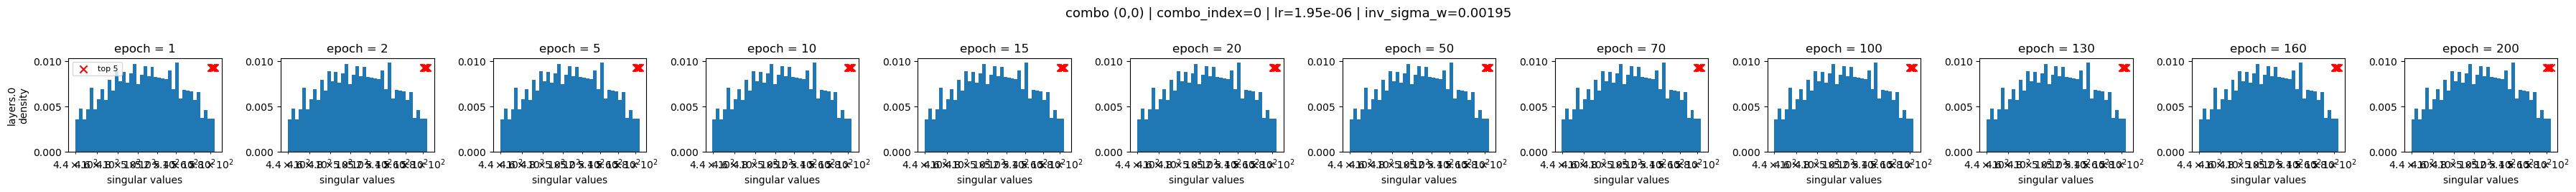

In [38]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

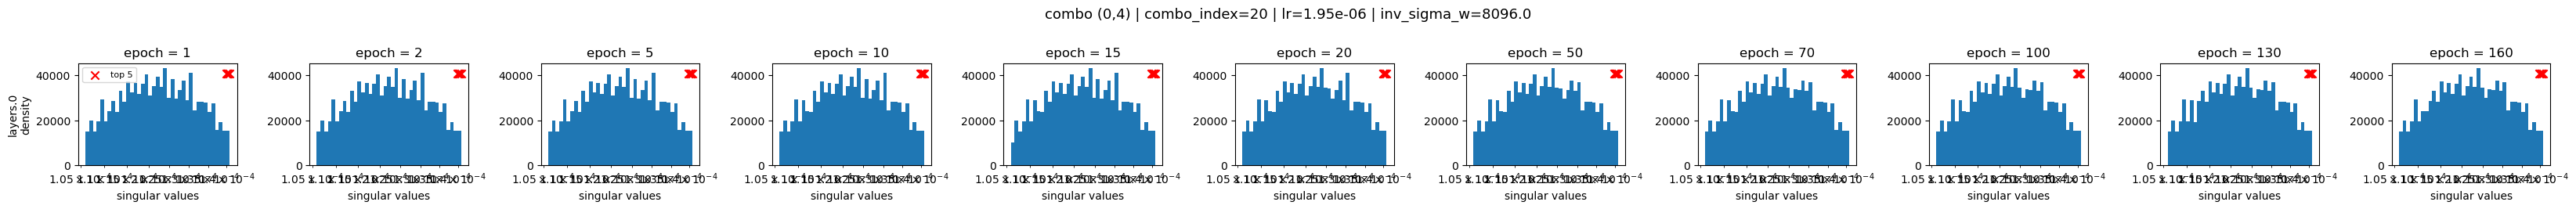

In [39]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

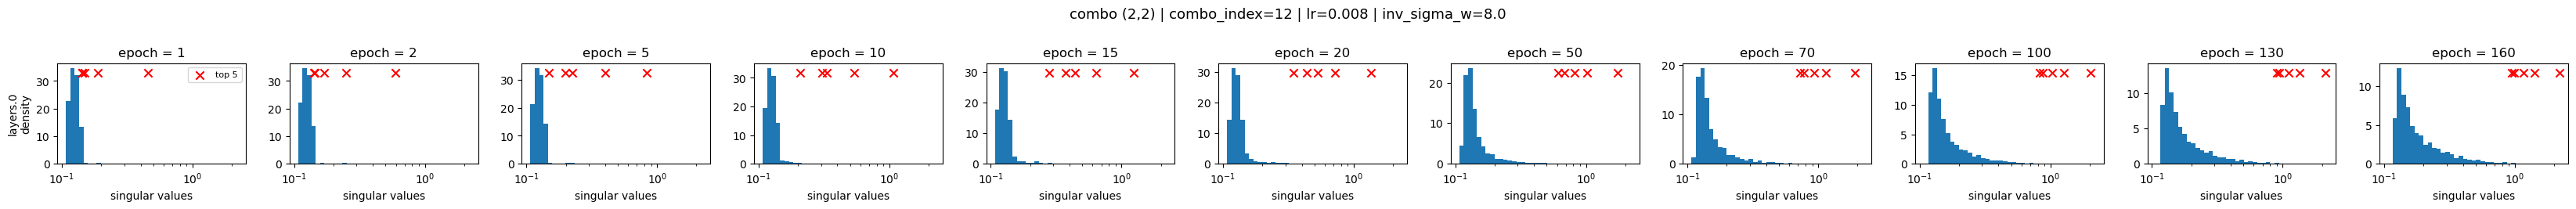

In [40]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=2,
    b=2,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

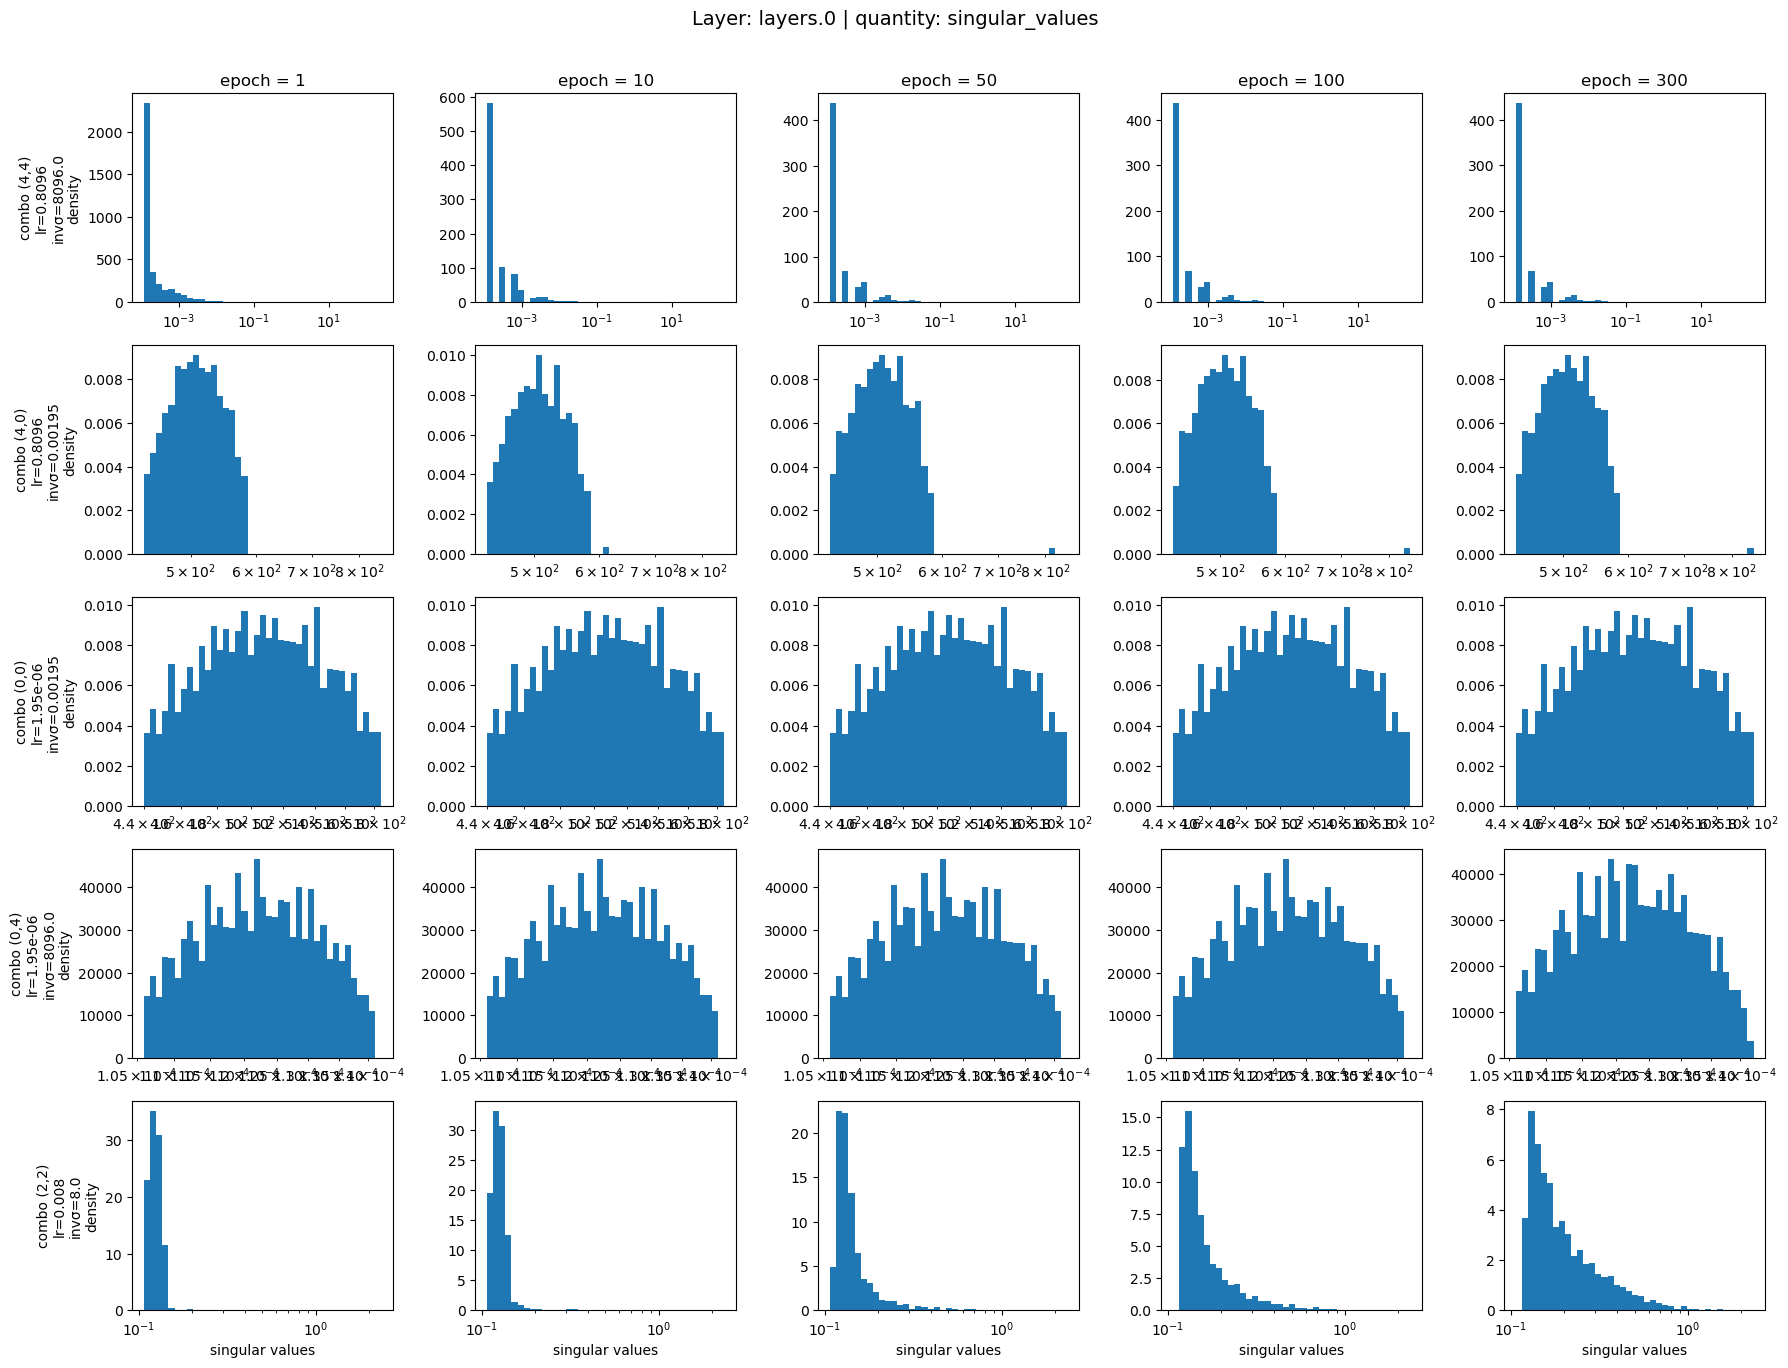

In [47]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.0",
    value_key="singular_values",
)

### 1 layer - tanh

In [4]:
results_dir = "data/experiment_2/exp2_SVD_dnn_SMALL_sgd_tanh_v1"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
)

[DONE] loaded 25 available (a,b) combos into memory.


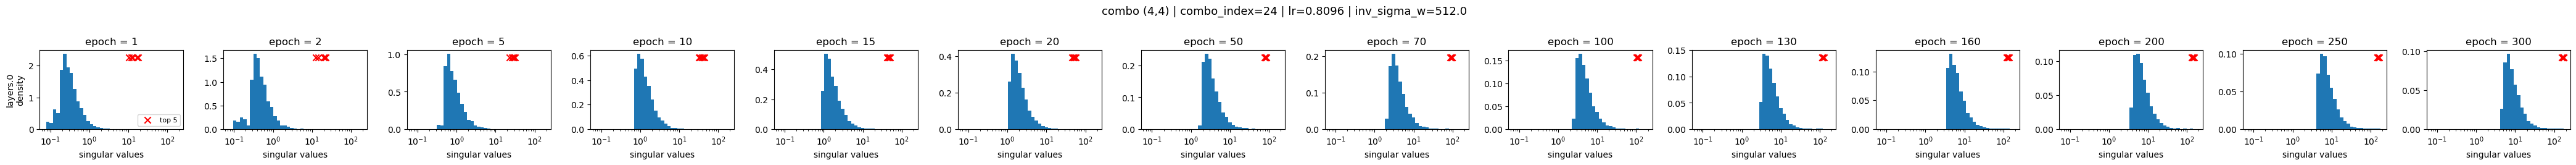

In [5]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

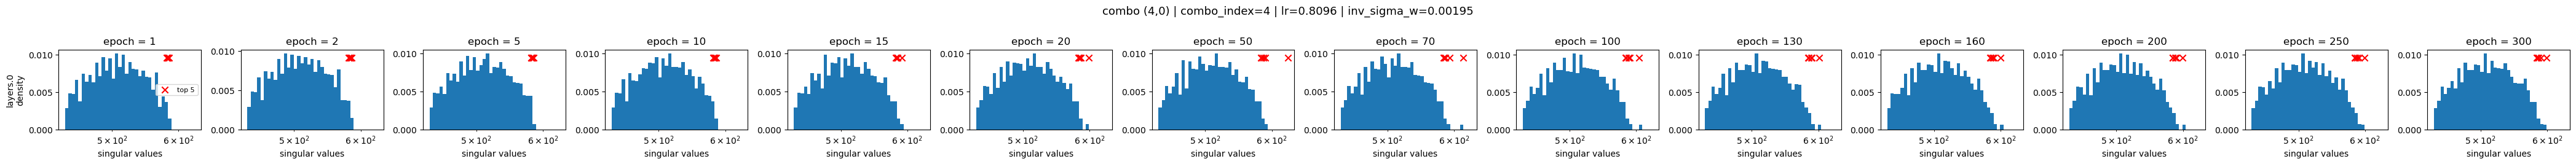

In [7]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

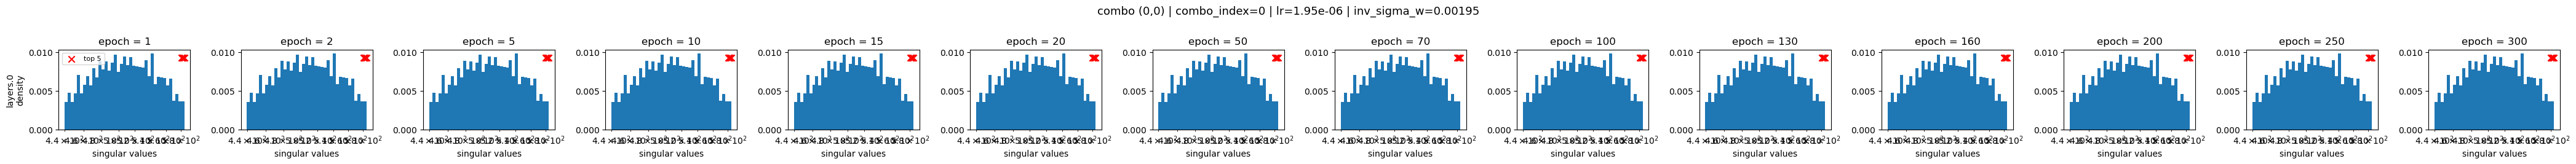

In [8]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=0,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

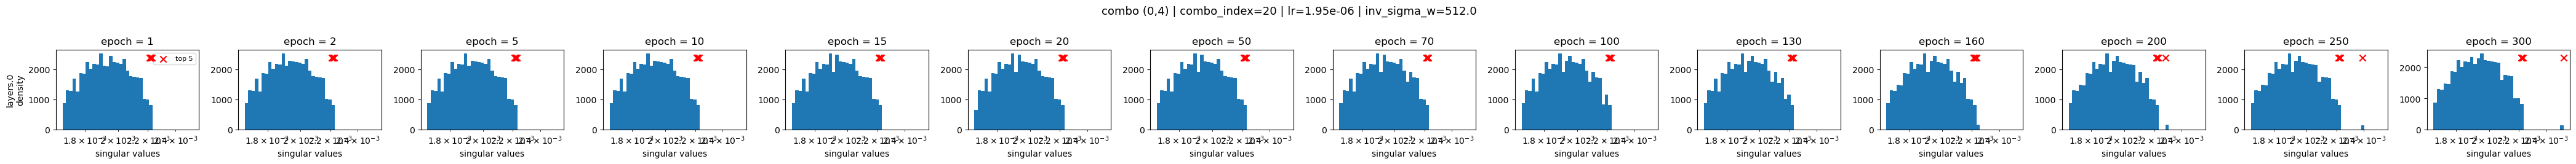

In [9]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=4,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

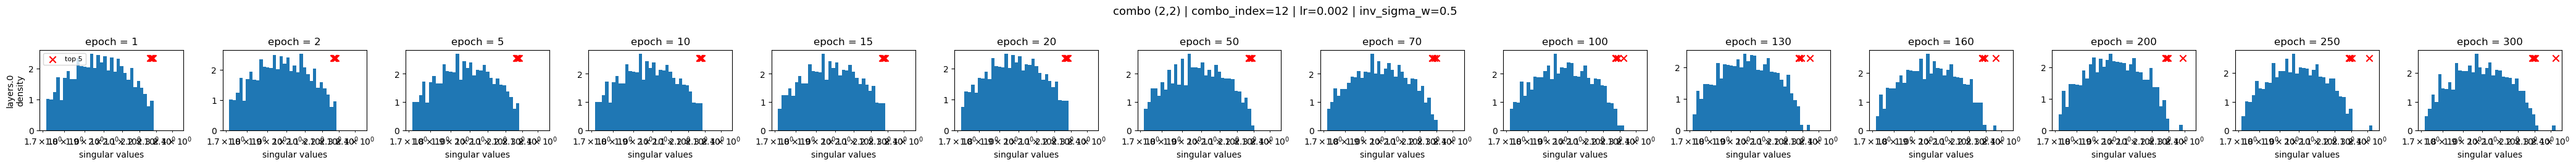

In [10]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=2,
    b=2,
    layers=["layers.0"],
    value_key="singular_values",
    bins=40,
    log_x=True,
    shared_bins="layer",
)

### 3 layers - relu

In [22]:
results_dir = "data/experiment_2/exp2_SVD_dnn_BIG_sgd_relu_v2"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram_BIG.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
)

[DONE] loaded 25 available (a,b) combos into memory.


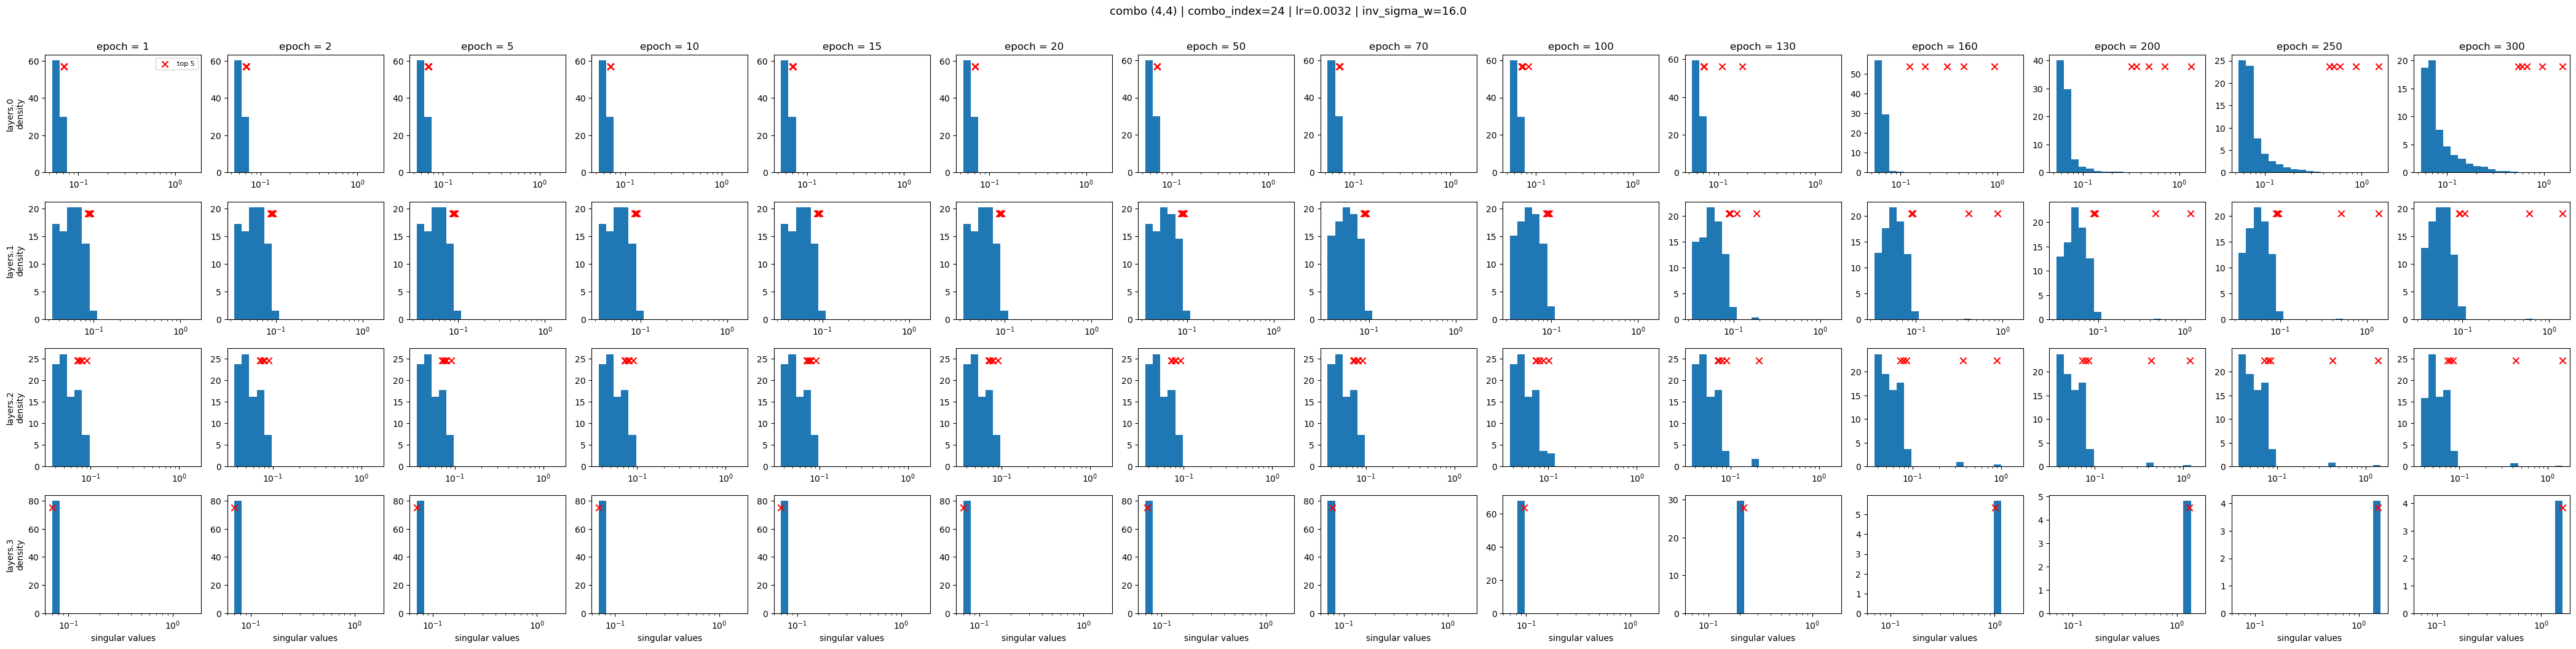

In [ ]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=4,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

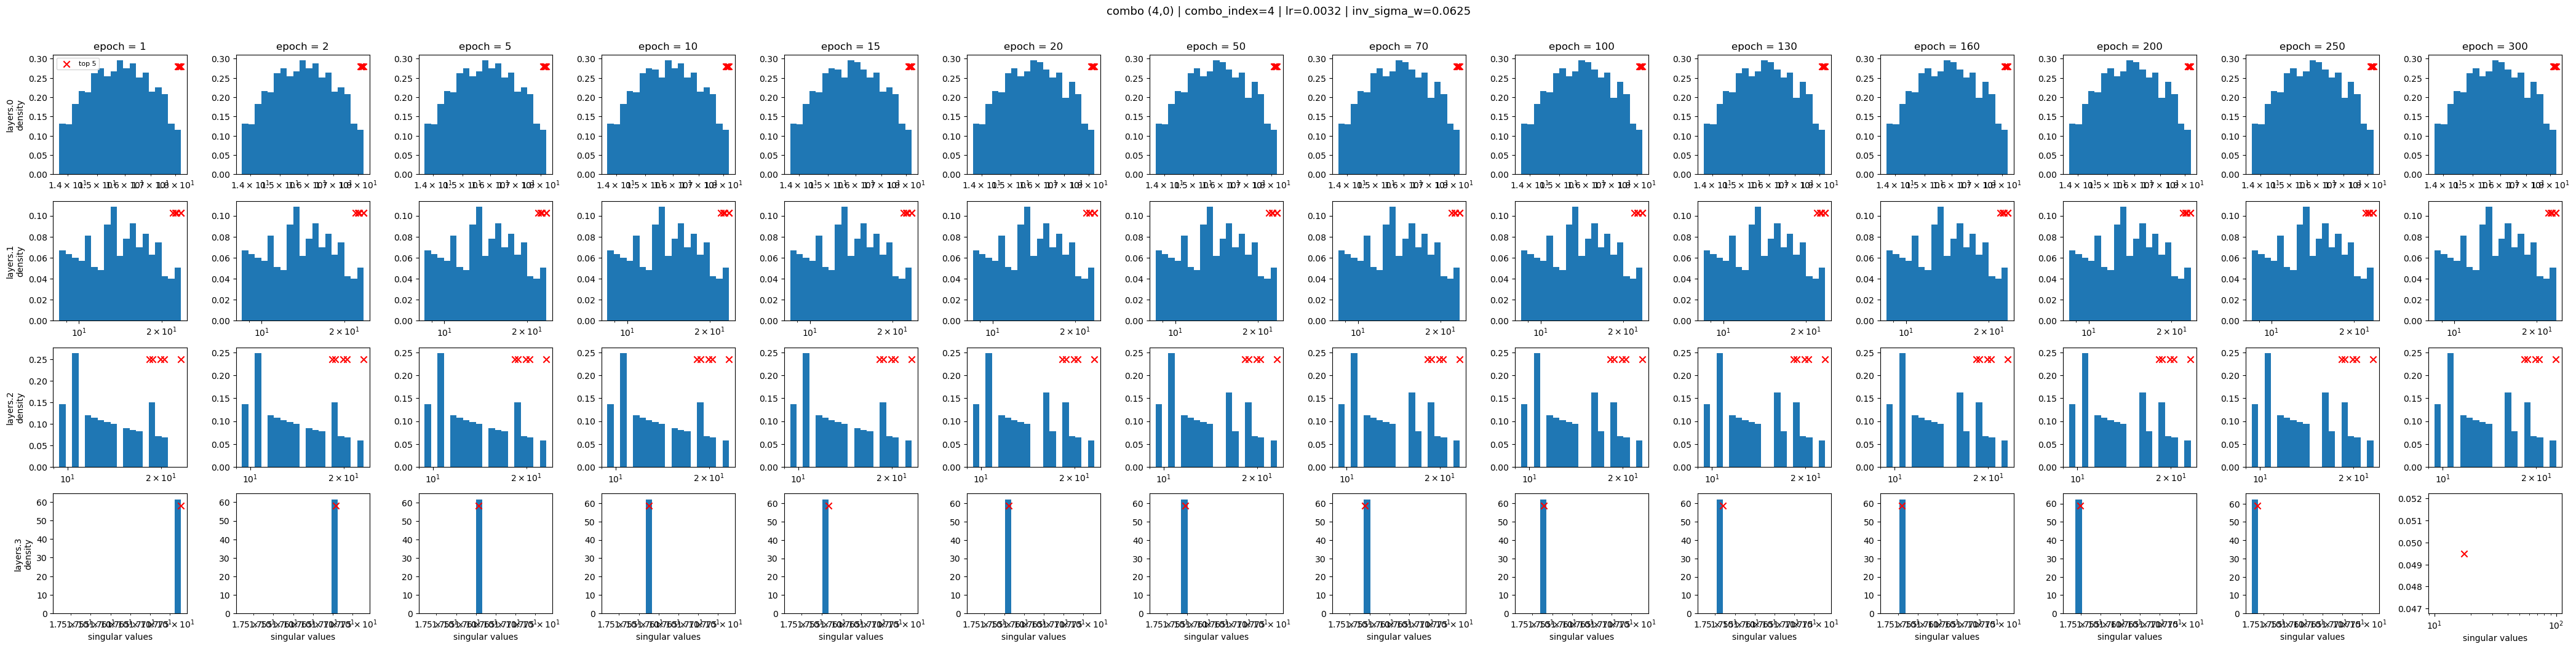

In [24]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=0,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

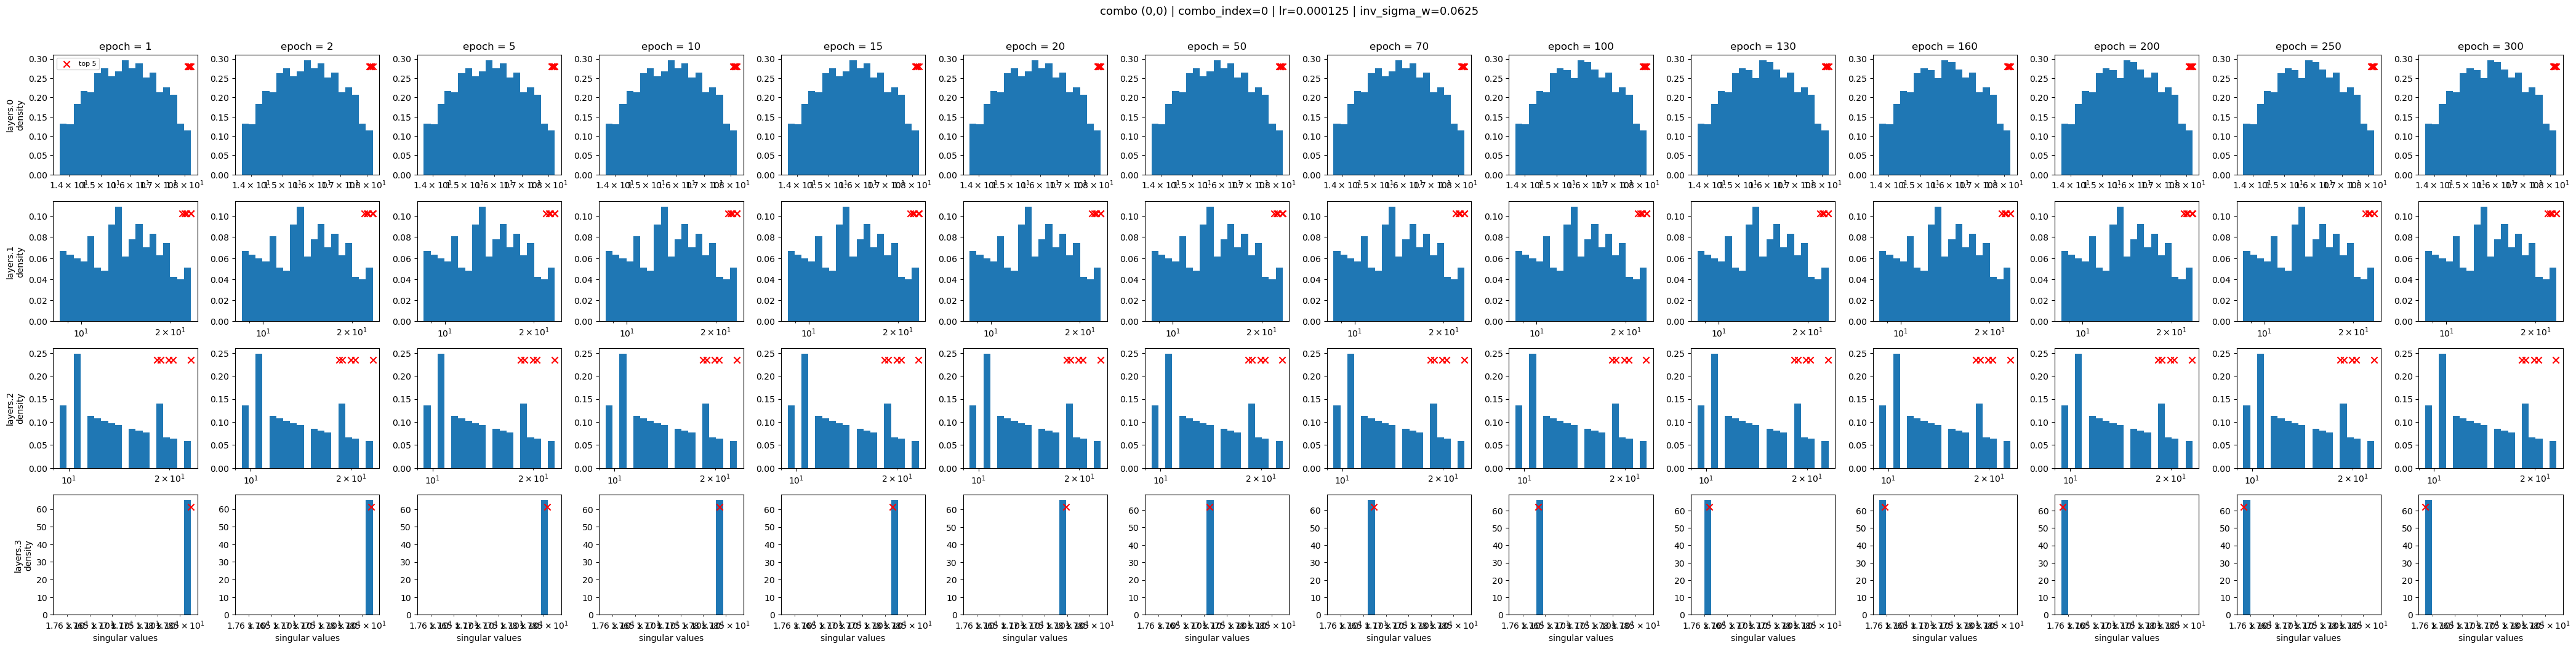

In [25]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=0,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

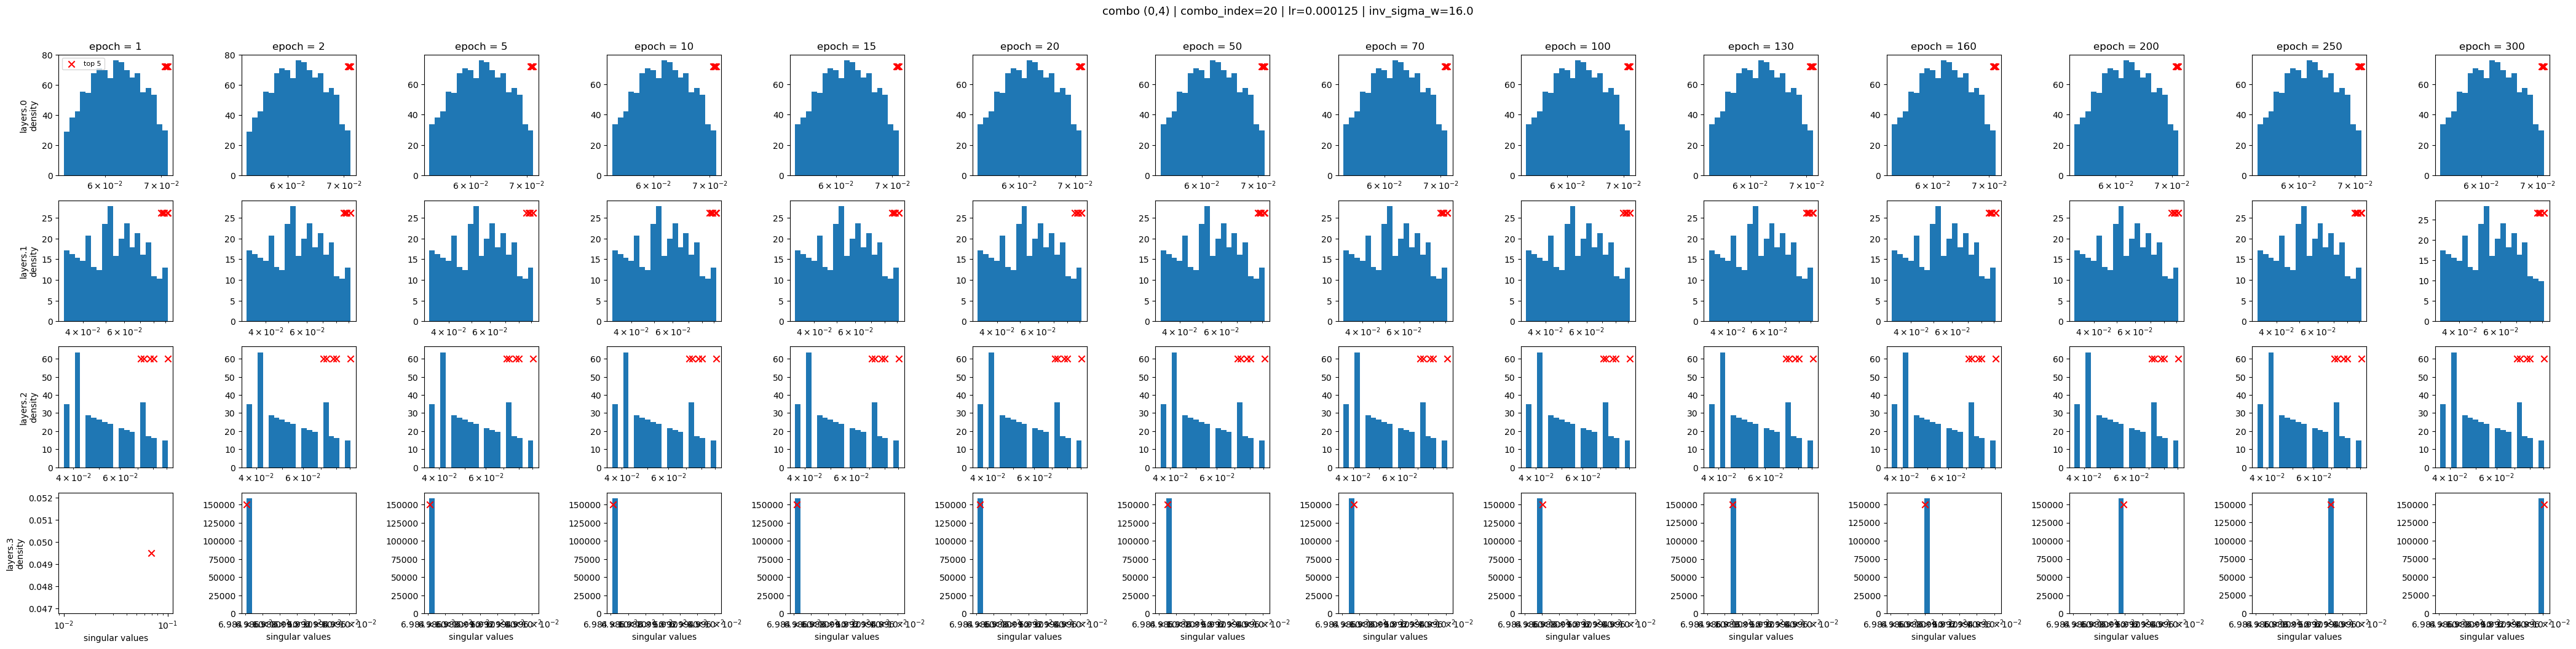

In [26]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=4,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

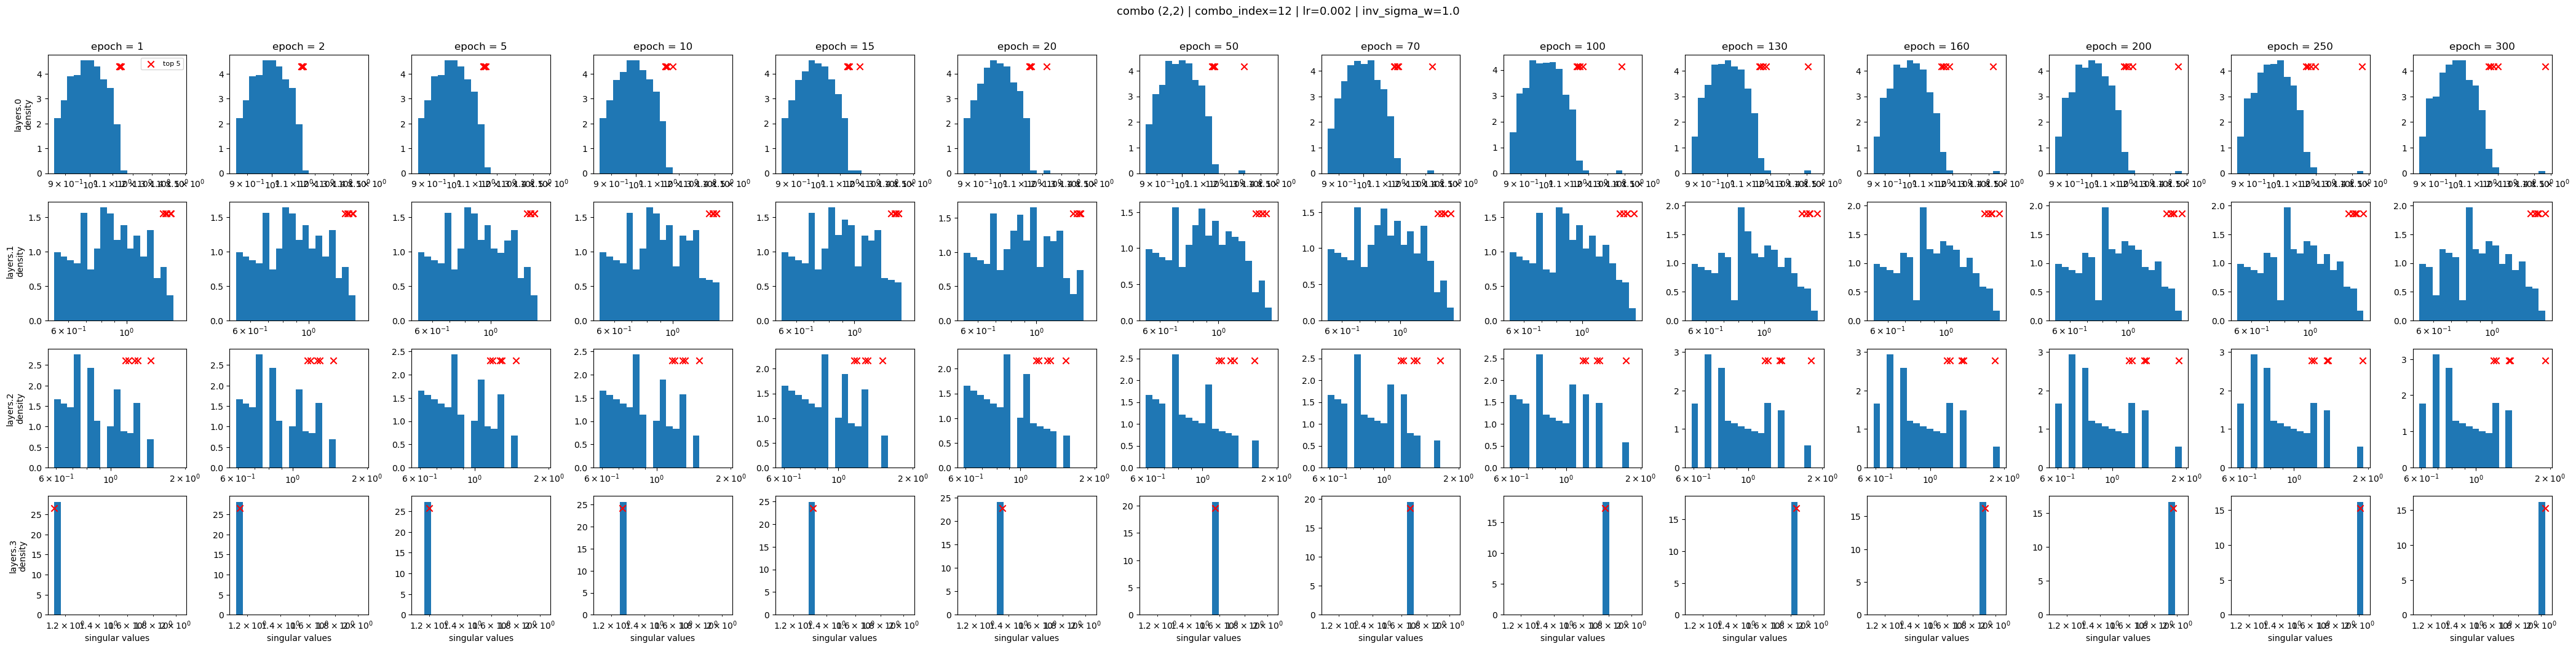

In [27]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=2,
    b=2,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

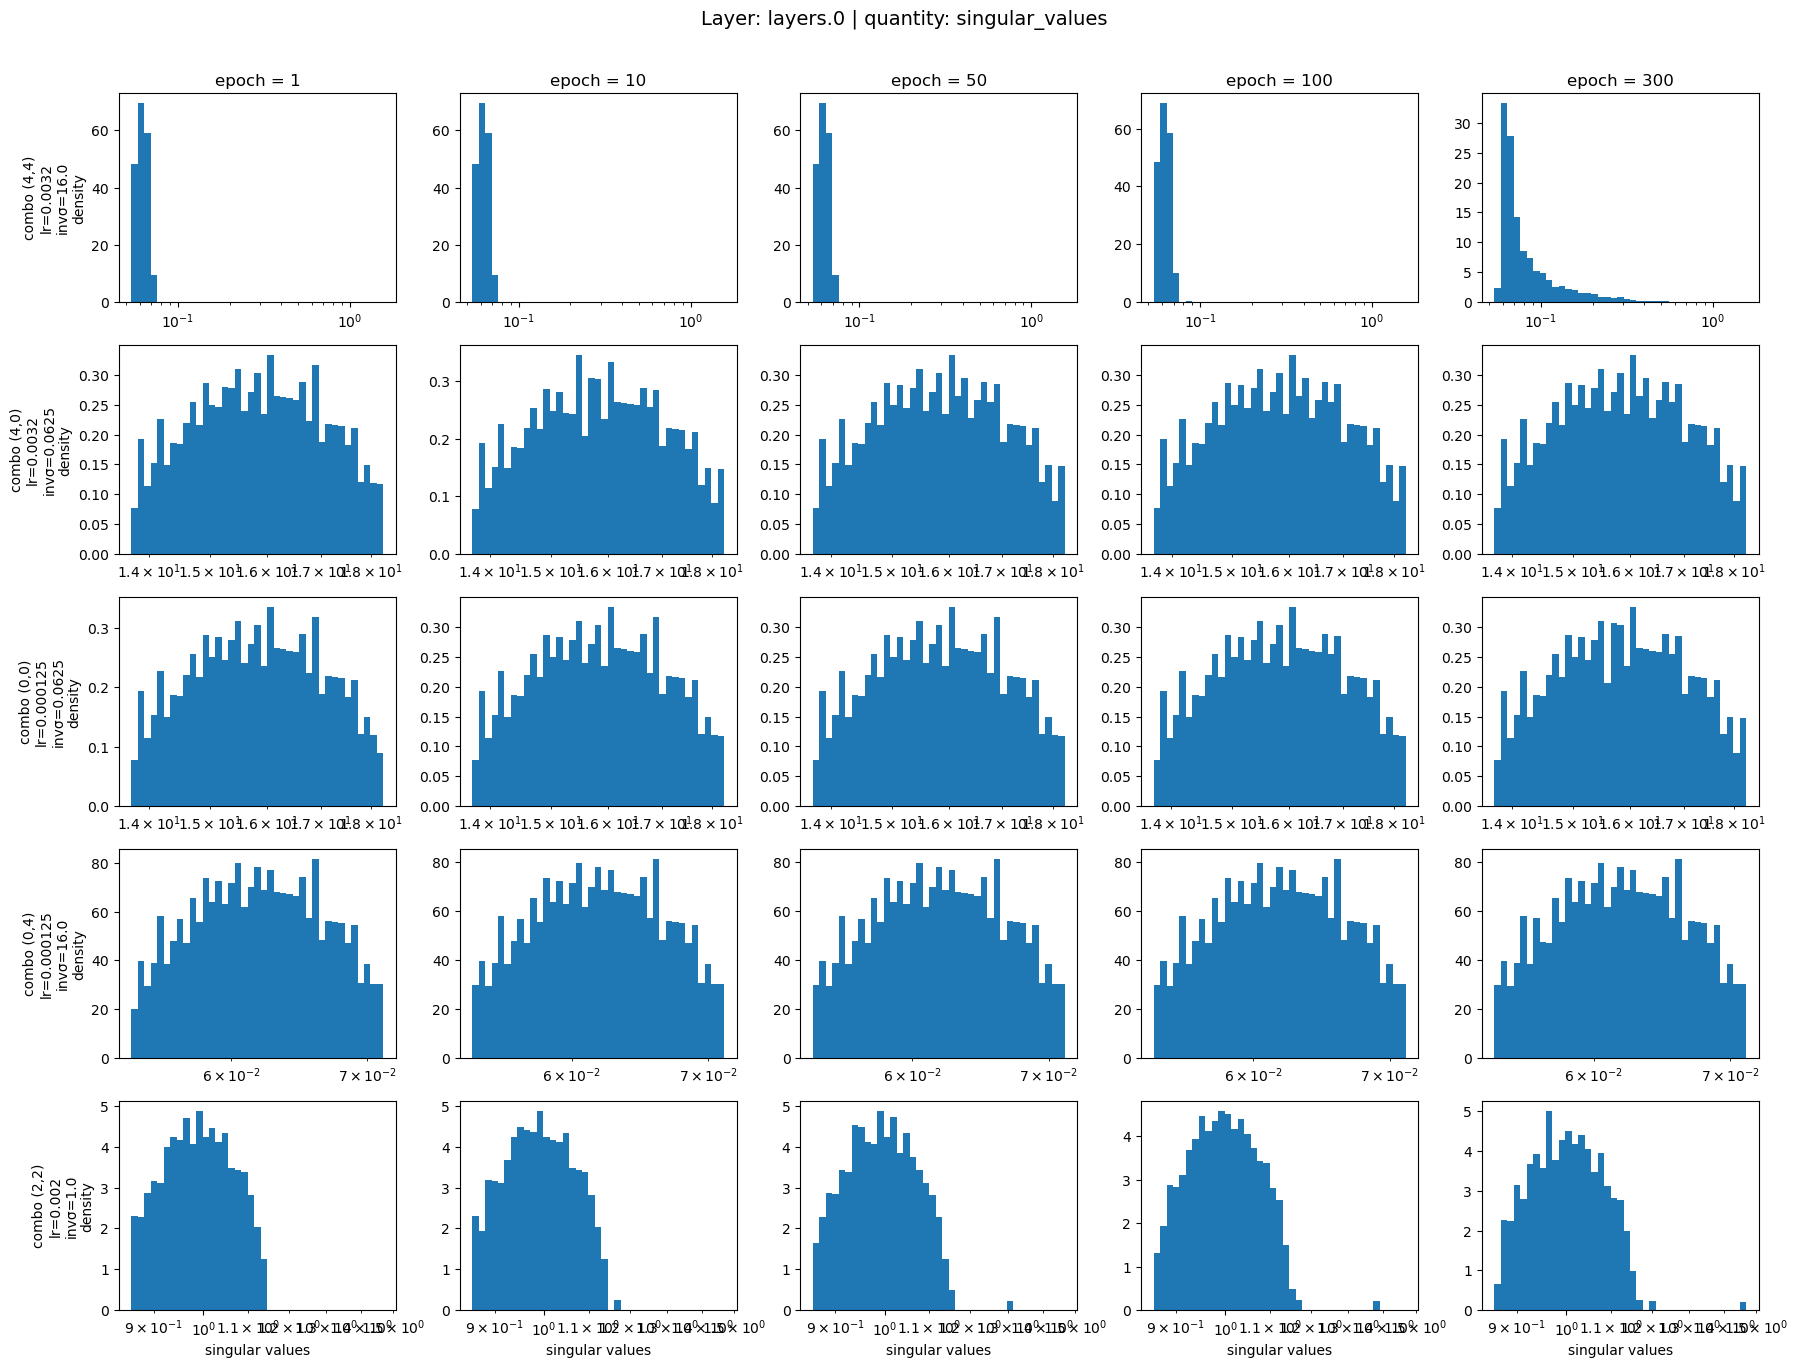

In [ ]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.0",
    value_key="singular_values",
)

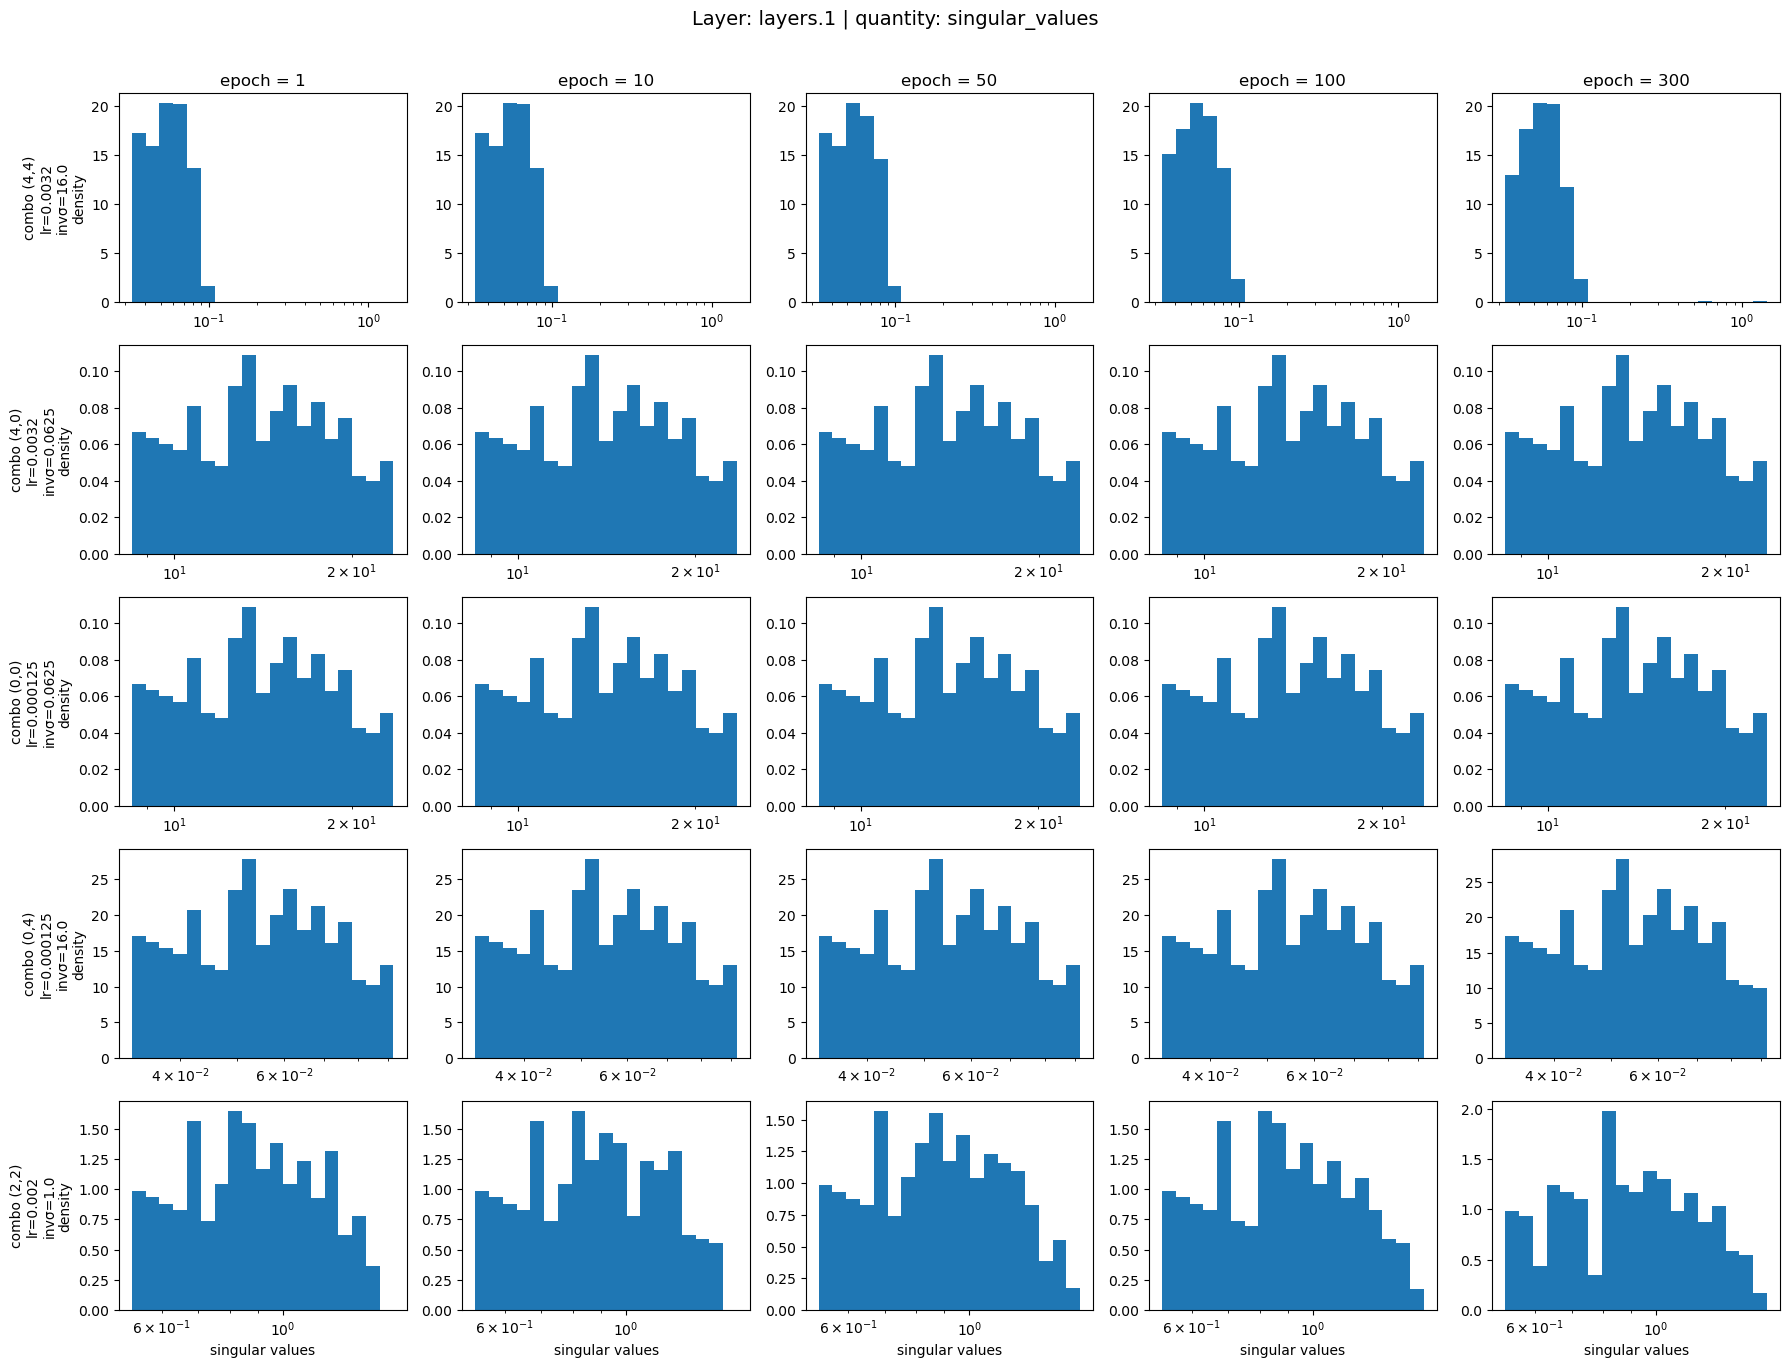

In [29]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.1",
    value_key="singular_values",
    bins=20
)

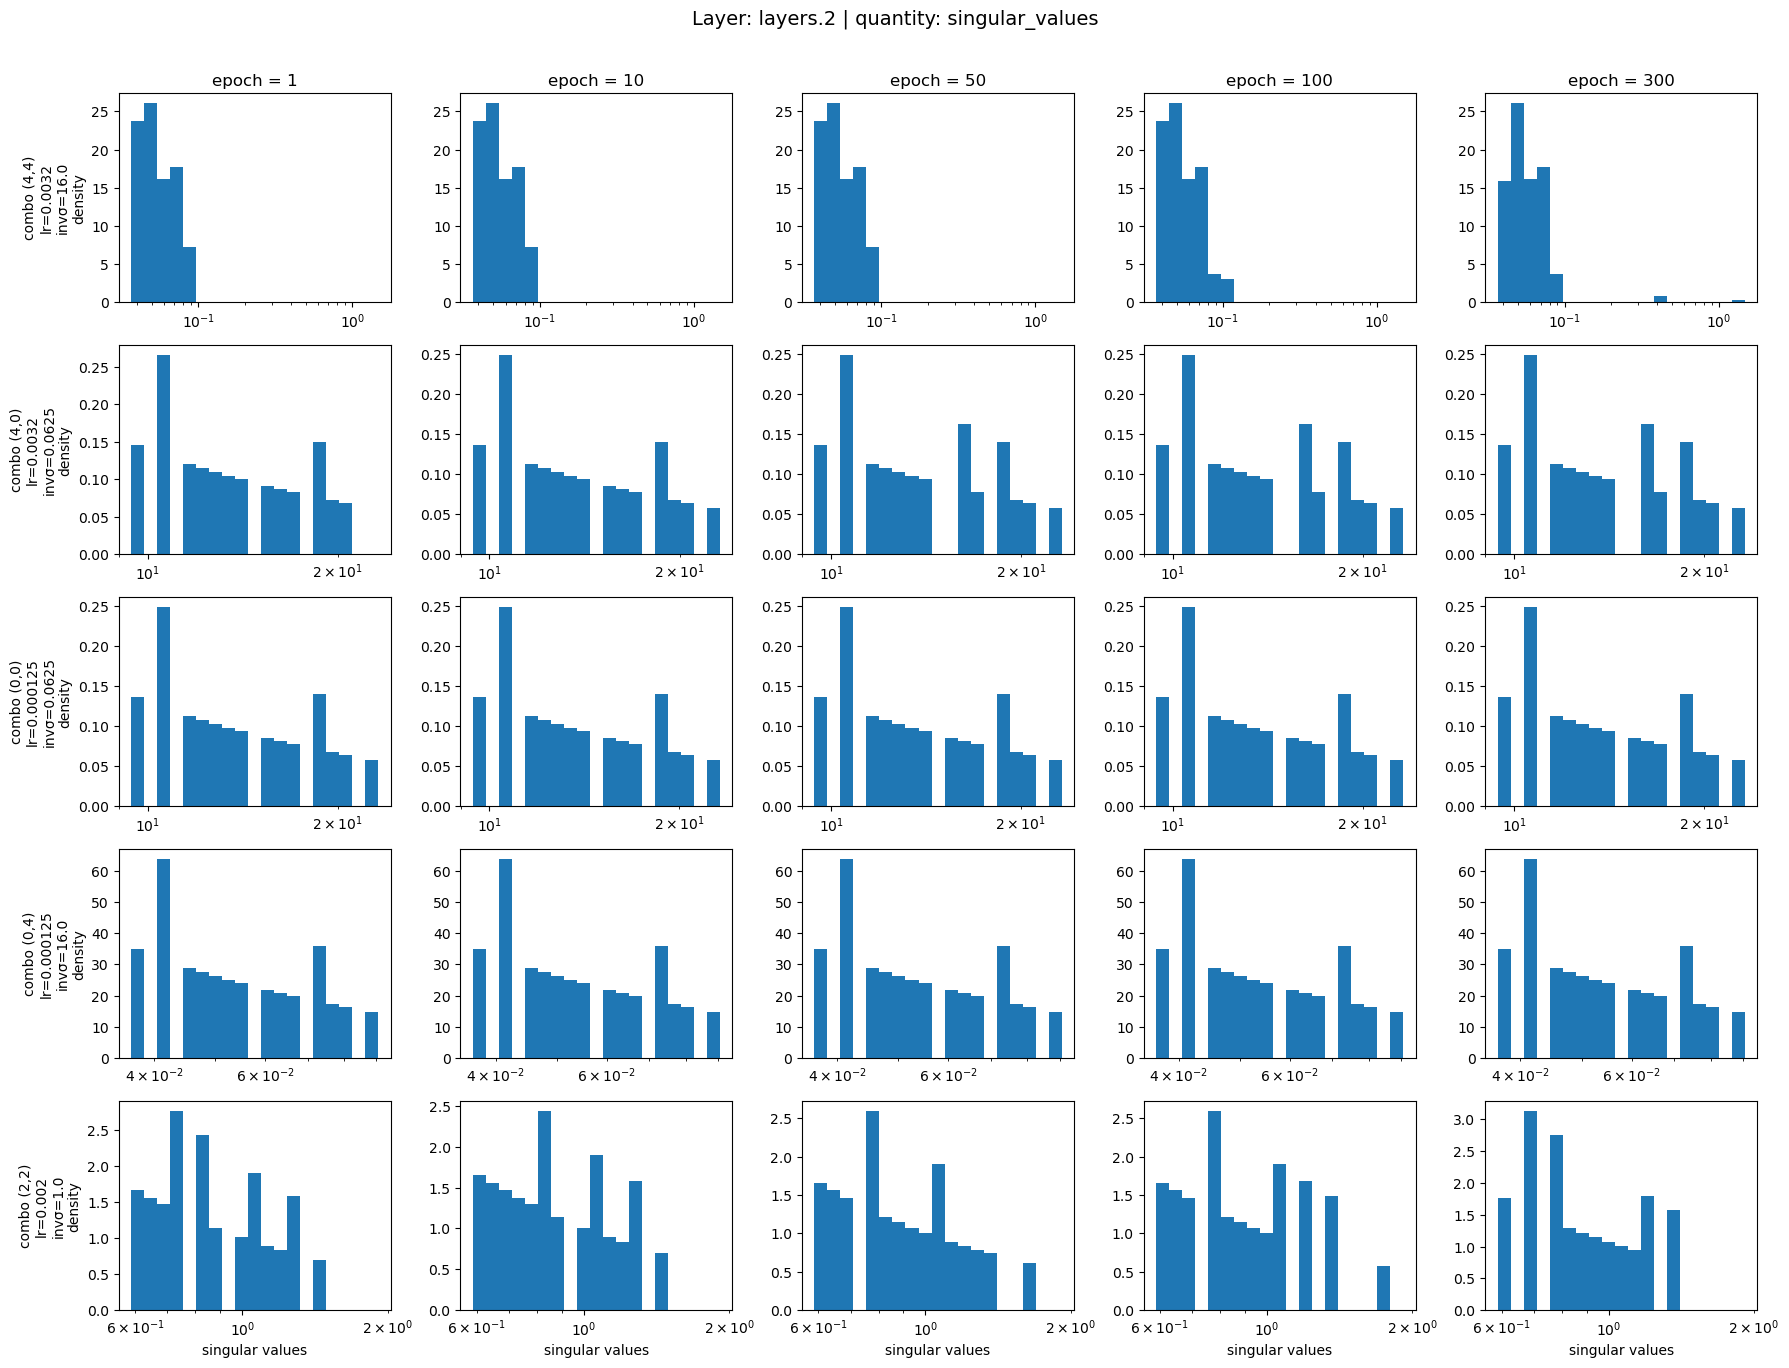

In [30]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.2",
    value_key="singular_values",
    bins=20
)

### 3 layer - tanh

In [11]:
results_dir = "data/experiment_2/exp2_SVD_dnn_BIG_sgd_tanh_v1"
config_path = "src/experiment_2/DNN_utkface_age_phase_diagram_BIG.json"

svd_store = load_all_svd_once(
    results_dir,
    config_path,
    svd_filename="svd_diagnostics.pt",
)

[DONE] loaded 25 available (a,b) combos into memory.


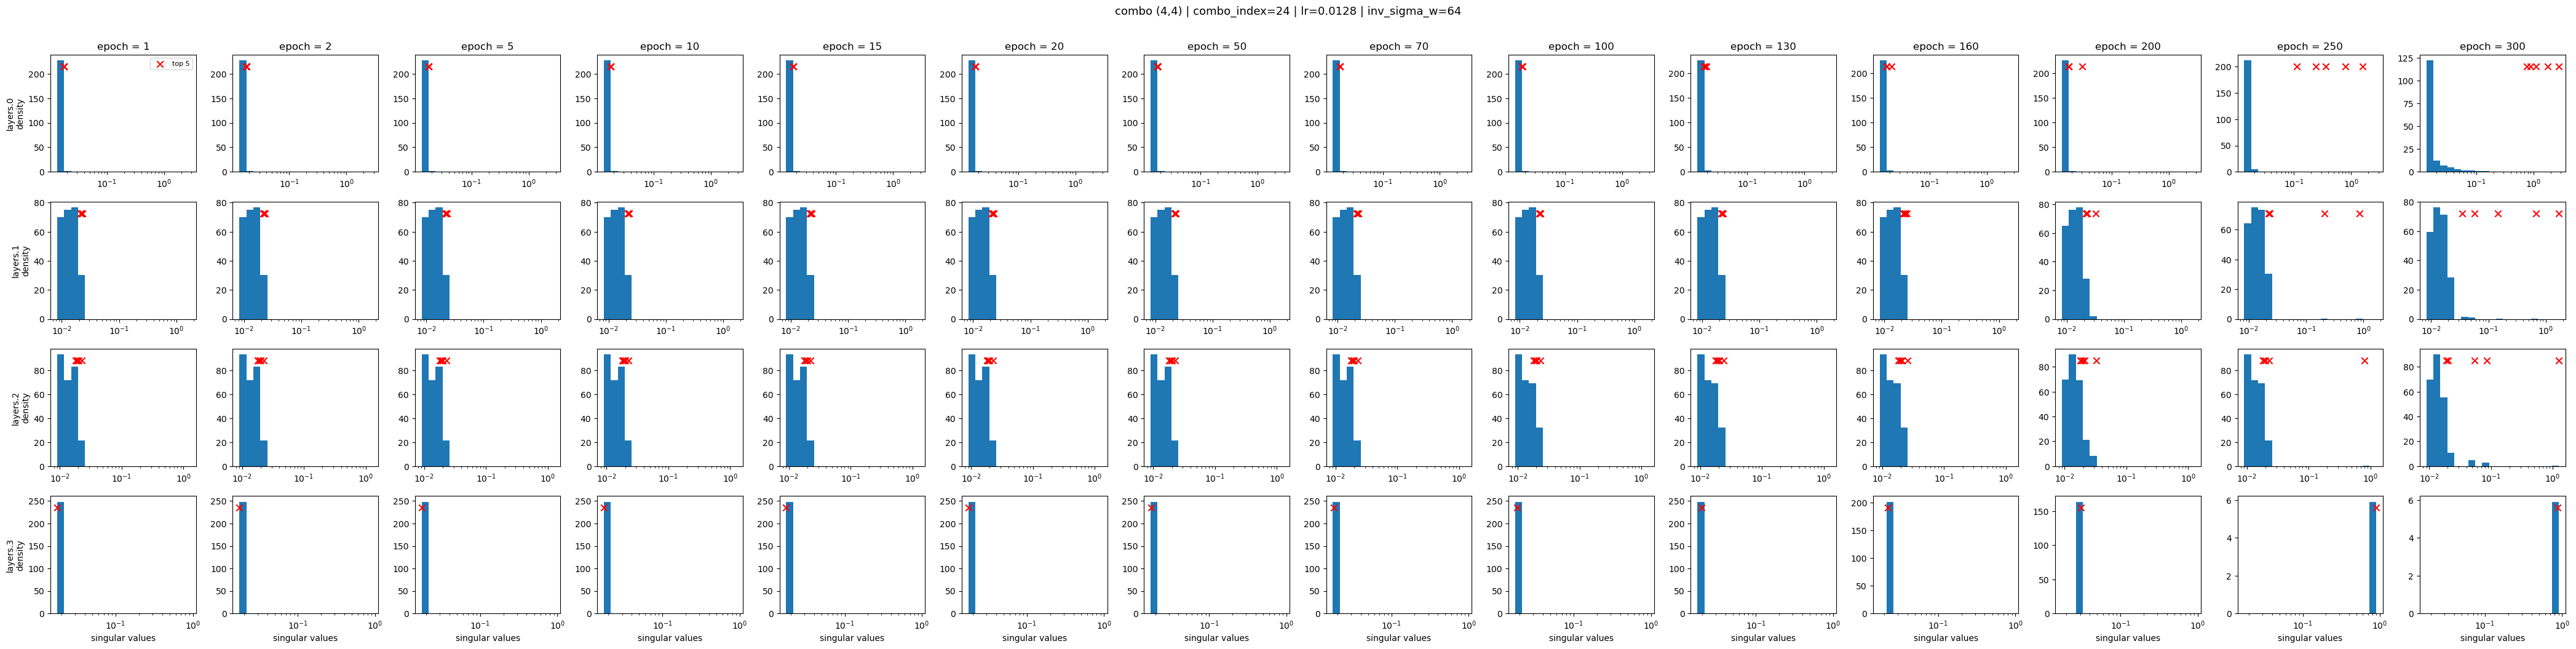

In [12]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=4,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

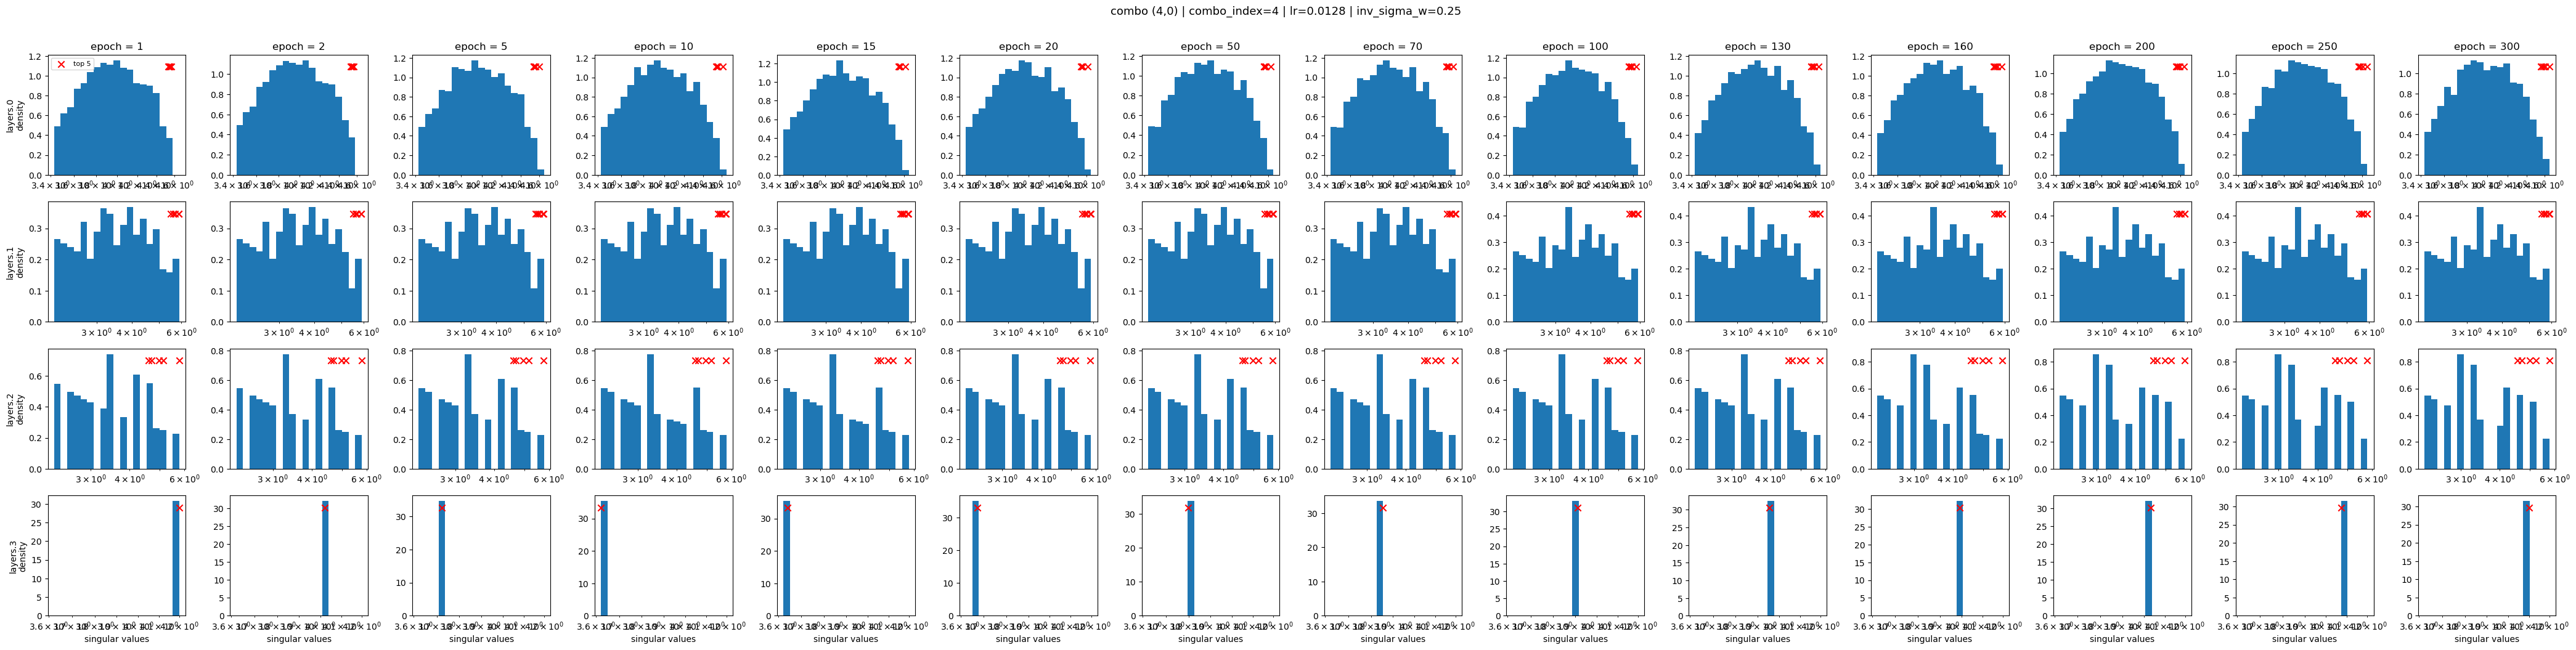

In [13]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=4,
    b=0,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

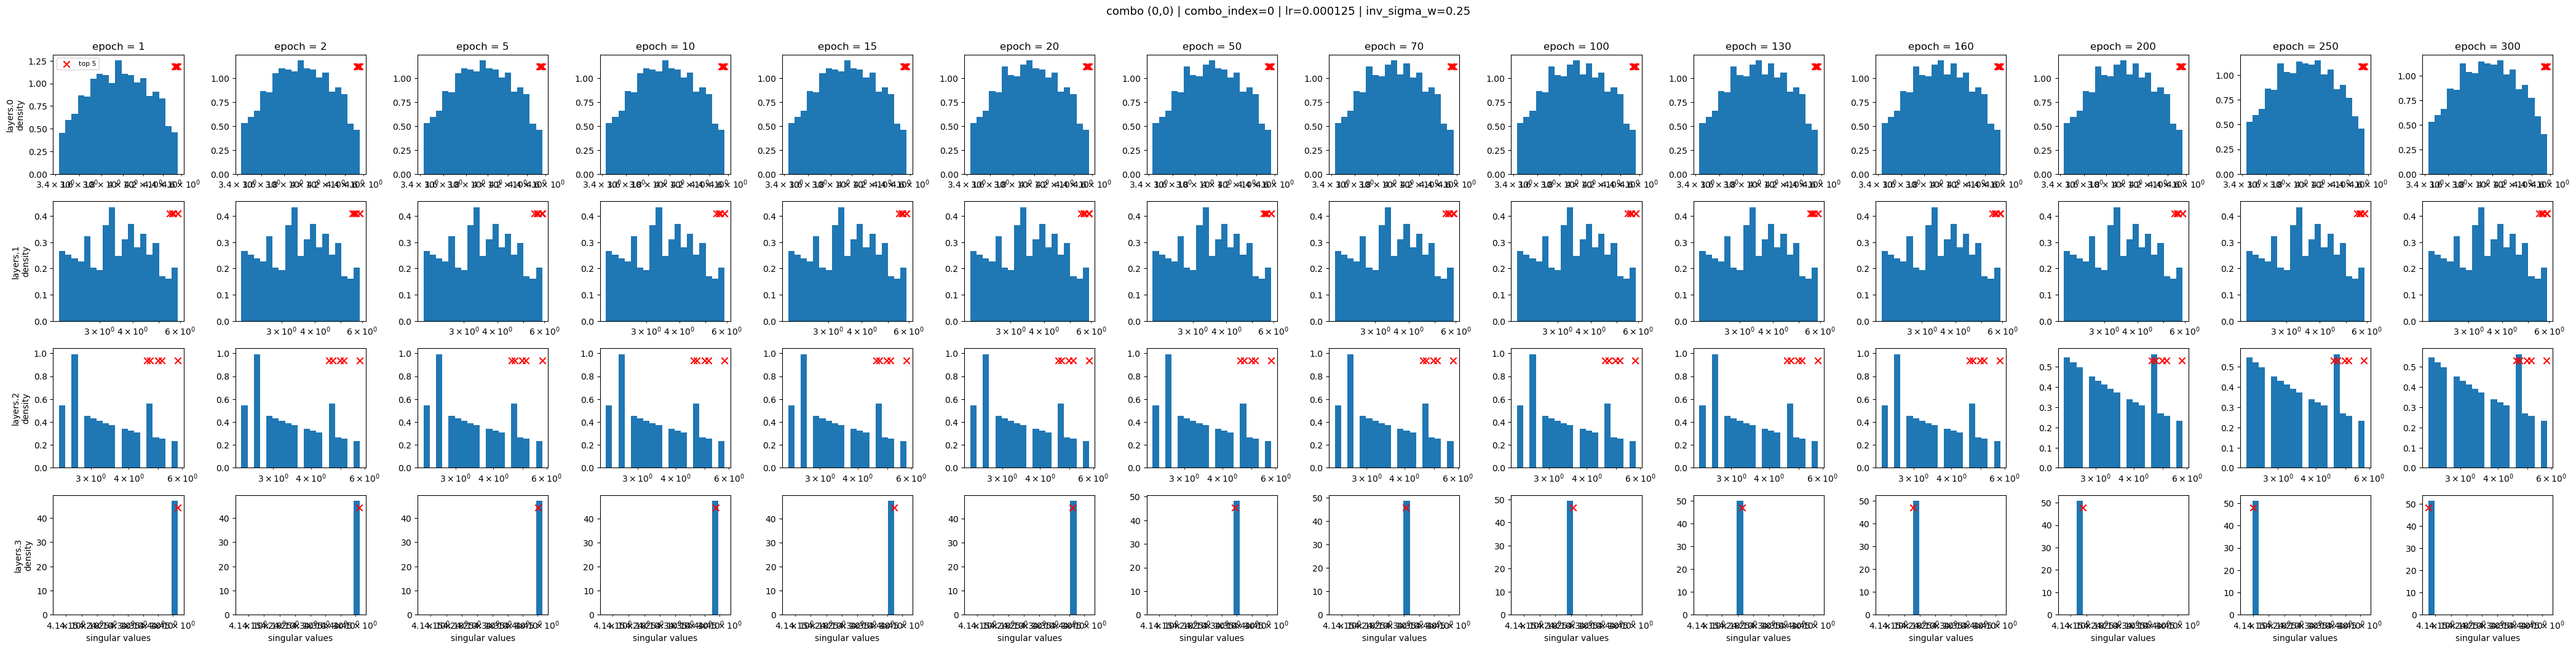

In [14]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=0,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

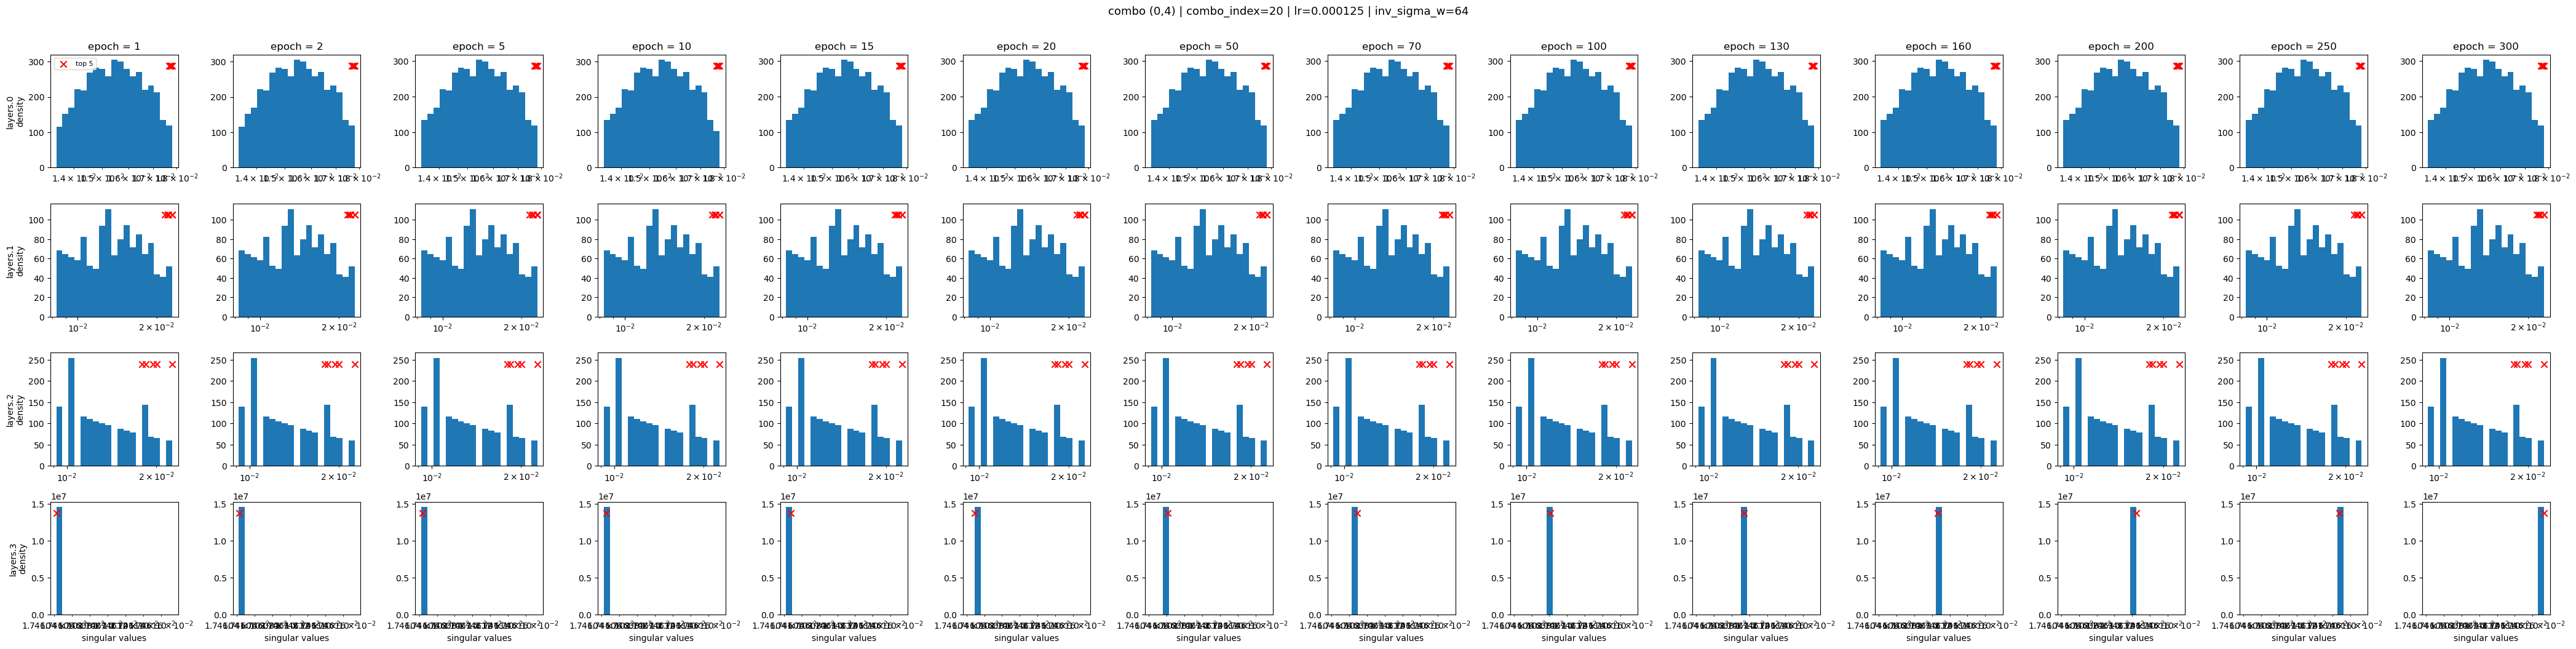

In [15]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=0,
    b=4,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

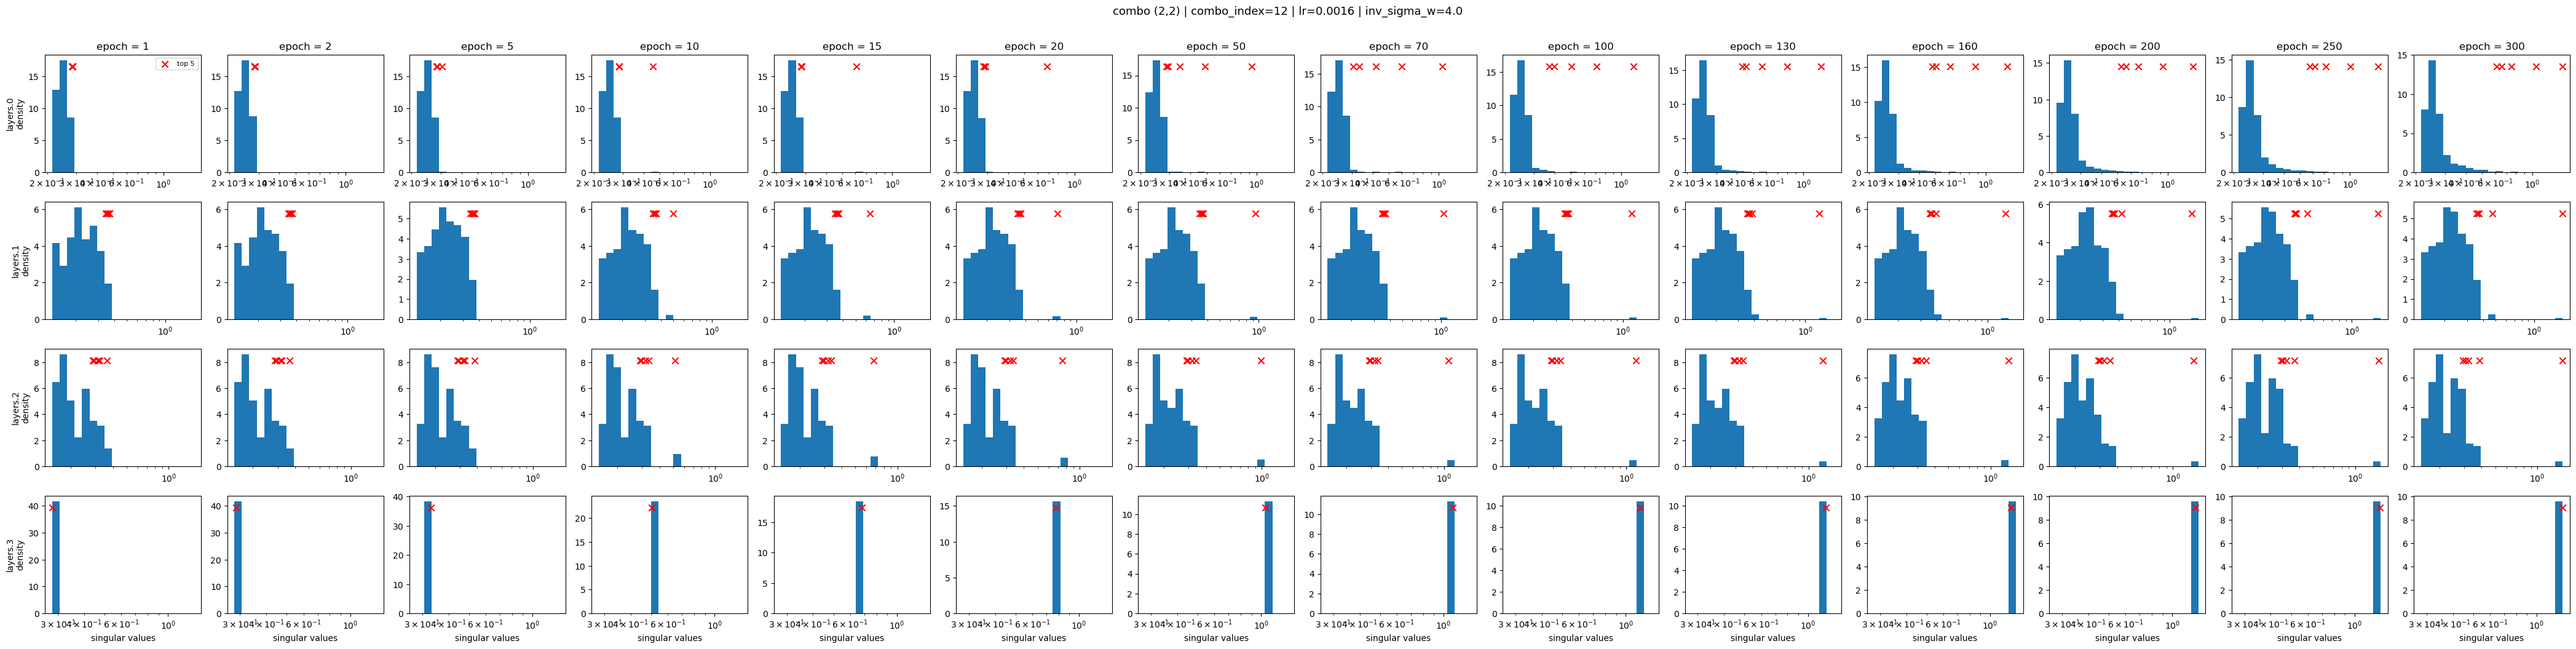

In [16]:
fig, axes = plot_svd_histograms_layers_by_time_from_store(
    svd_store,
    a=2,
    b=2,
    layers="all",
    value_key="singular_values",
    bins=20,
    log_x=True,
    shared_bins="layer",
)

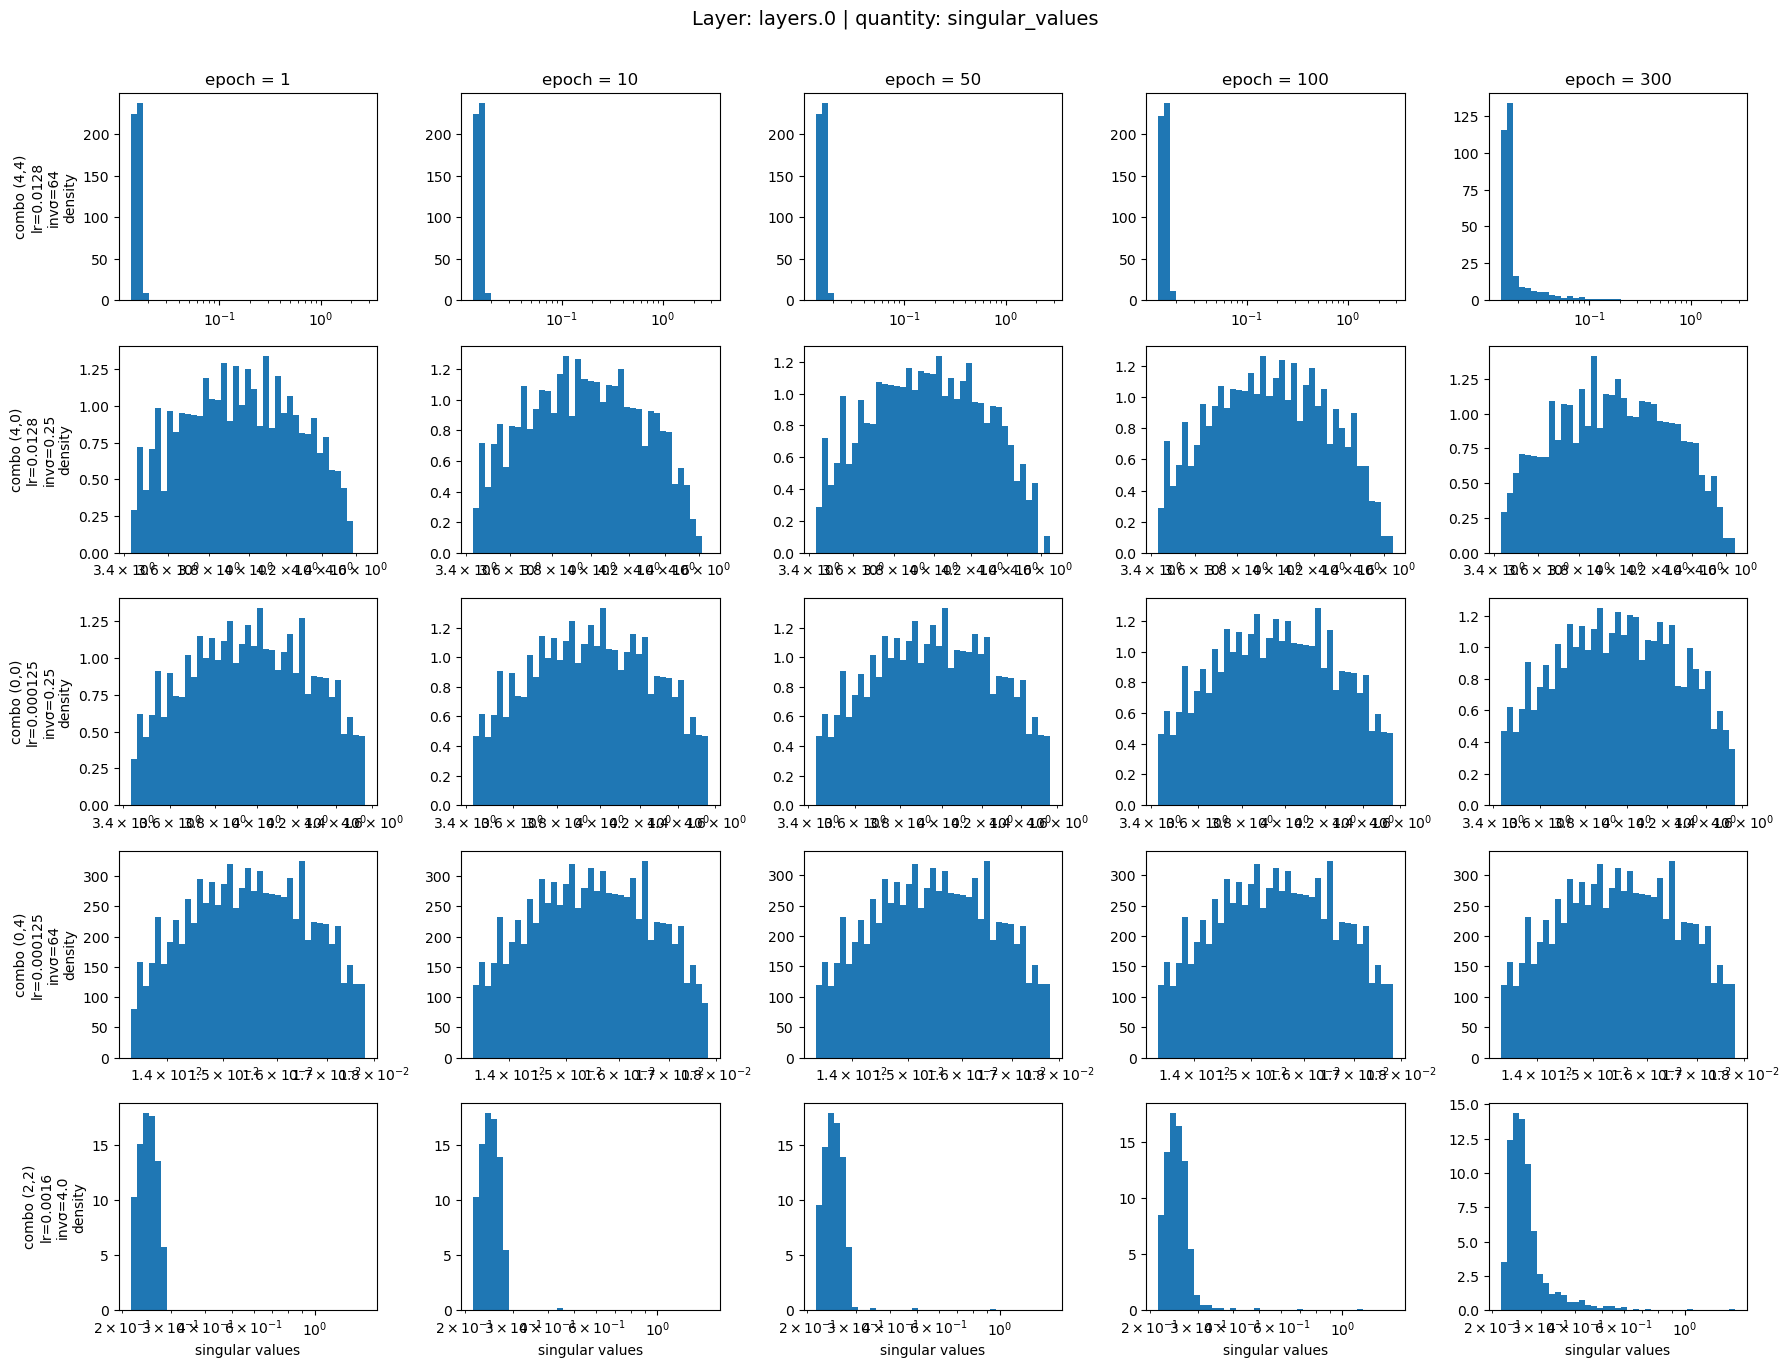

In [17]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.0",
    value_key="singular_values",
)

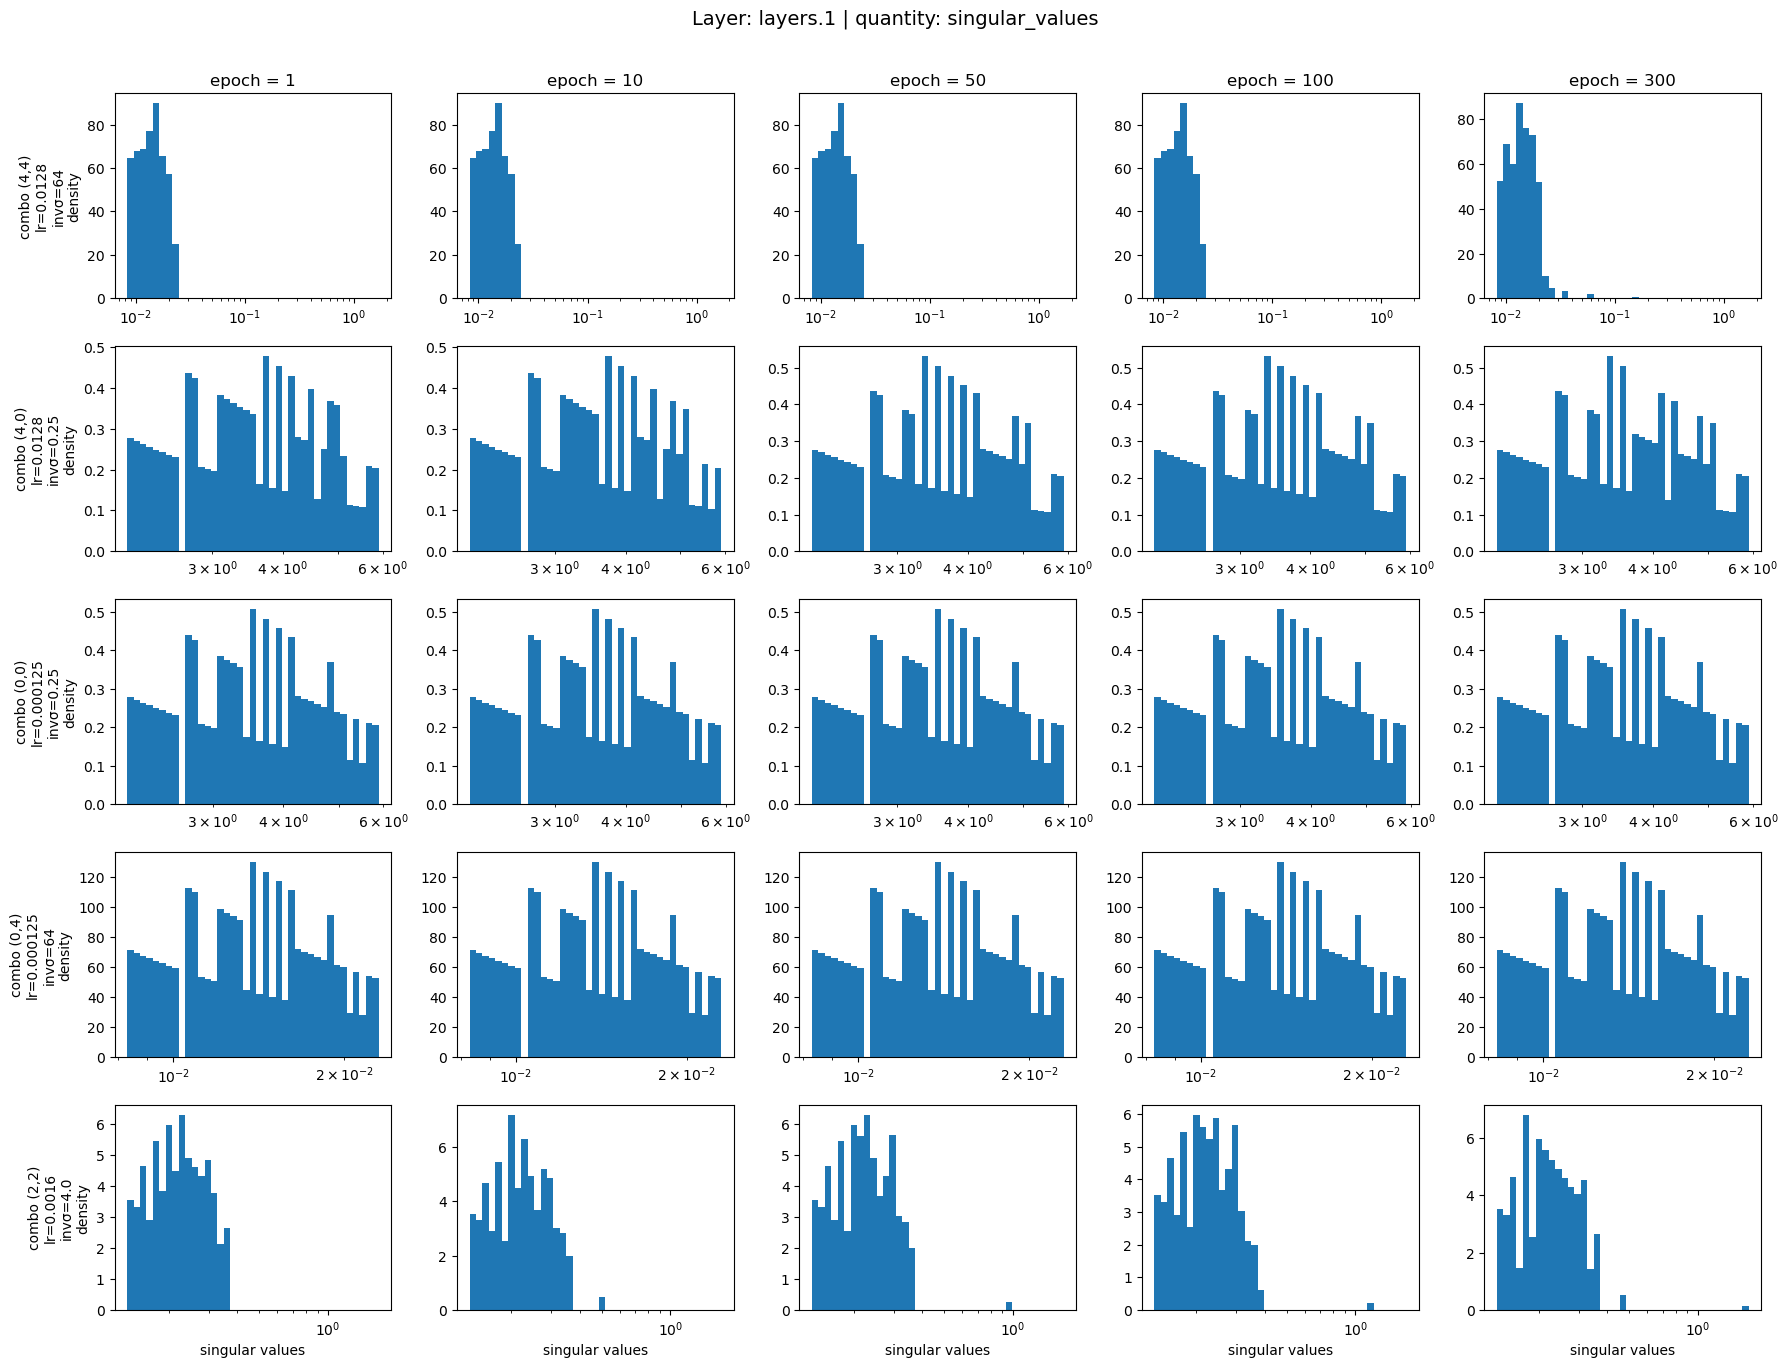

In [18]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.1",
    value_key="singular_values",
)

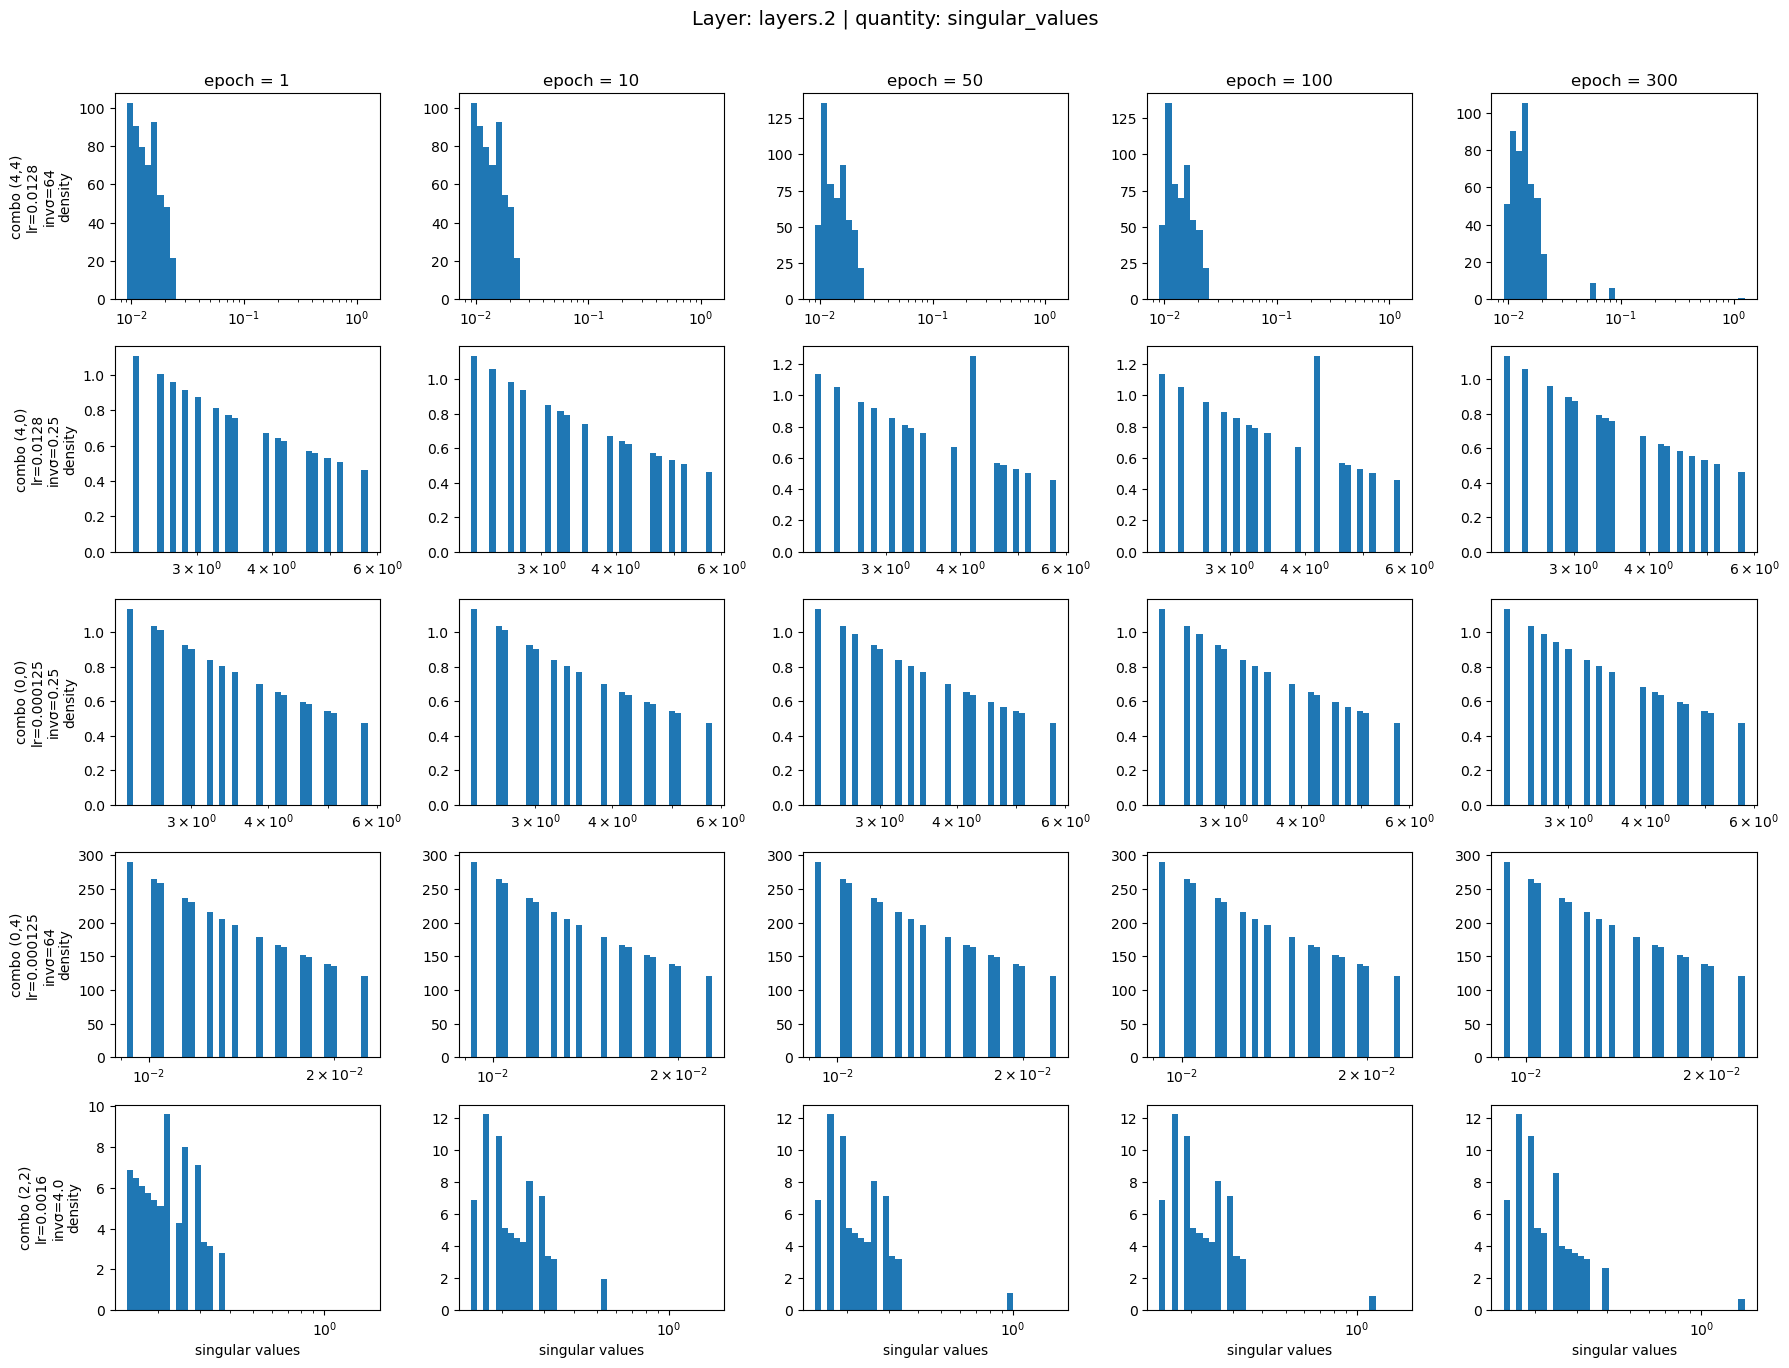

In [19]:
fig, axes = plot_svd_histograms_combos_by_time_from_store(
    svd_store,
    combo_list=[(4,4), (4, 0), (0,0), (0,4), (2, 2)],
    validation_times=[1, 10, 50, 100, 300],
    layer="layers.2",
    value_key="singular_values",
)